In [2]:
import numpy as np
import pandas as pd

import io
import os
import tensorflow as tf

from PIL import Image
from glob import glob
import itertools

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from IPython.display import display
#To see the value of multiple statements at once.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
""" import os
import shutil
import pandas as pd

# Paths
image_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\ISIC_Images"
metadata_path = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\metadata.csv"

# ✅ Updated output path
output_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\sorted images"

# Read metadata
df = pd.read_csv(metadata_path)

# Process each image
for _, row in df.iterrows():
    isic_id = row['isic_id'].strip()
    label = str(row['diagnosis']).strip().replace("/", "-")

    filename = f"{isic_id}.jpg"
    src_path = os.path.join(image_dir, filename)
    dst_folder = os.path.join(output_dir, label)
    dst_path = os.path.join(dst_folder, filename)

    os.makedirs(dst_folder, exist_ok=True)

    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
    else:
        print(f"Missing file: {filename}")
  """

Missing file: ISIC_0080539.jpg


'C:\\Users\\abdur\\vs_code\\Sidra-Tasks\\sidra thesis\\Research Methadology Project-20250403T120511Z-0011\\Research Methadology Project\\Datasets\\PROVe-AI datset\\sorted images\\lichenoid keratosis\\ISIC_0098024.jpg'

Missing file: ISIC_0131983.jpg


'C:\\Users\\abdur\\vs_code\\Sidra-Tasks\\sidra thesis\\Research Methadology Project-20250403T120511Z-0011\\Research Methadology Project\\Datasets\\PROVe-AI datset\\sorted images\\lentigo NOS\\ISIC_0134155.jpg'

Missing file: ISIC_0155910.jpg
Missing file: ISIC_0178370.jpg


...

'C:\\Users\\abdur\\vs_code\\Sidra-Tasks\\sidra thesis\\Research Methadology Project-20250403T120511Z-0011\\Research Methadology Project\\Datasets\\PROVe-AI datset\\sorted images\\lichenoid keratosis\\ISIC_9859134.jpg'

'C:\\Users\\abdur\\vs_code\\Sidra-Tasks\\sidra thesis\\Research Methadology Project-20250403T120511Z-0011\\Research Methadology Project\\Datasets\\PROVe-AI datset\\sorted images\\melanoma\\ISIC_9859873.jpg'

'C:\\Users\\abdur\\vs_code\\Sidra-Tasks\\sidra thesis\\Research Methadology Project-20250403T120511Z-0011\\Research Methadology Project\\Datasets\\PROVe-AI datset\\sorted images\\seborrheic keratosis\\ISIC_9876659.jpg'

Missing file: ISIC_9881460.jpg
Missing file: ISIC_9881690.jpg


'C:\\Users\\abdur\\vs_code\\Sidra-Tasks\\sidra thesis\\Research Methadology Project-20250403T120511Z-0011\\Research Methadology Project\\Datasets\\PROVe-AI datset\\sorted images\\nevus\\ISIC_9918922.jpg'

# read the data

=== Loading PROVe-AI Dataset ===
Base directory: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset
Found CSV files: ['C:\\Users\\abdur\\vs_code\\Sidra-Tasks\\sidra thesis\\Research Methadology Project-20250403T120511Z-0011\\Research Methadology Project\\Datasets\\PROVe-AI datset\\metadata.csv']
Loaded CSV with 603 rows and 30 columns
Columns: ['isic_id', 'attribution', 'copyright_license', 'acquisition_day', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'benign_malignant', 'clin_size_long_diam_mm', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_5', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'mel_class', 'mel_thick_mm', 'mel_ulcer', 'melanocytic', 'nevus_type', 'patient_id', 'personal_hx_mm', 'sex']

=== Preprocessing Data ===
Available columns

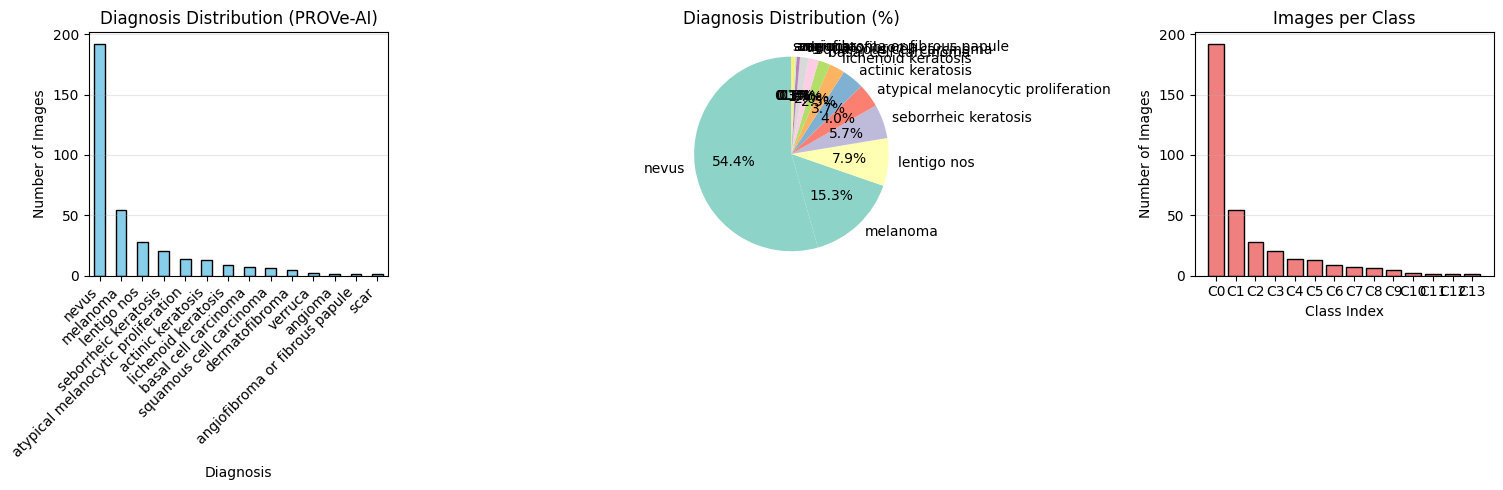


=== Visualizing Sample Images ===
Found 14 unique diagnoses


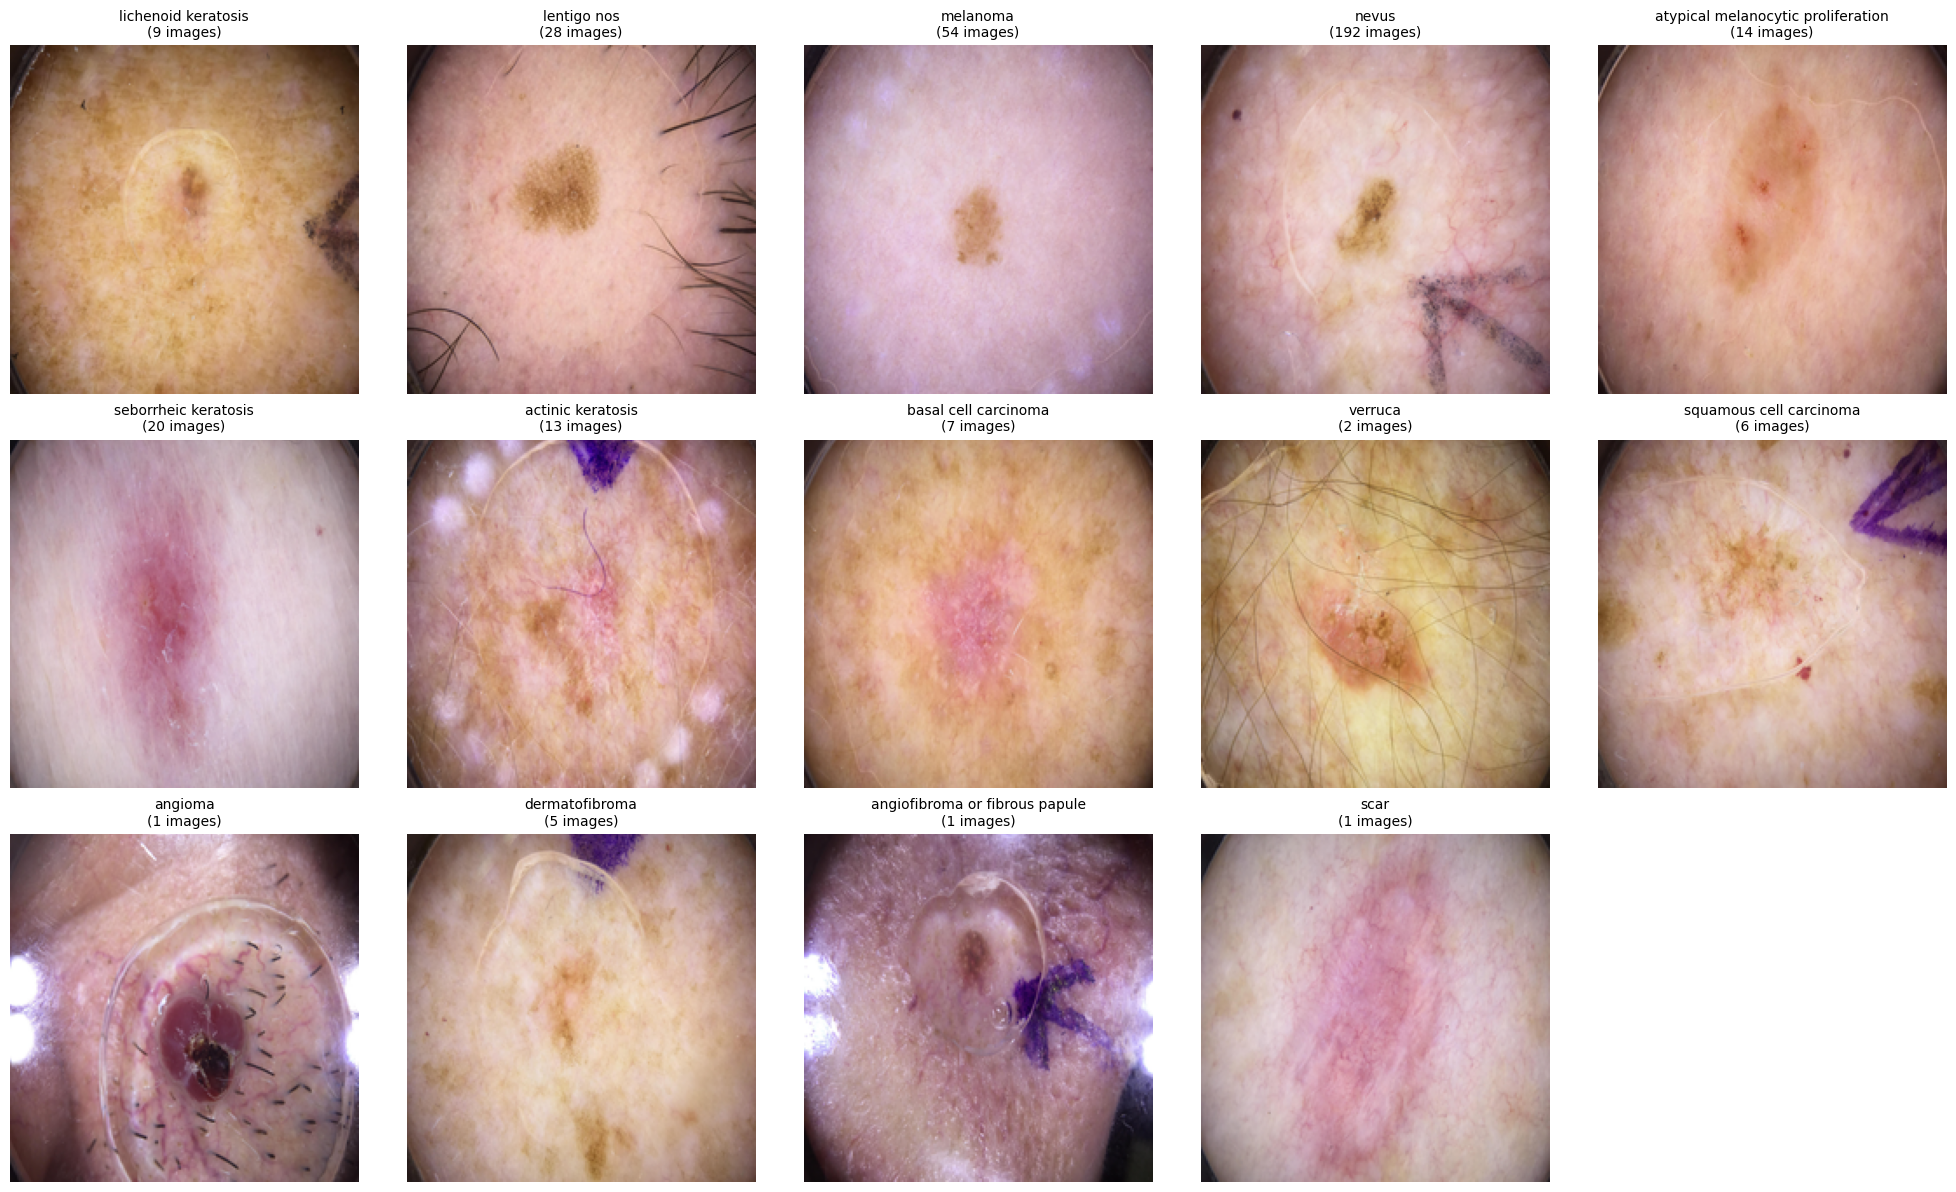


PROVe-AI dataset exploration complete!
Final dataset shape: (353, 13)


In [5]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

def load_prove_ai_dataset(base_dir):
    """Load and explore the PROVe-AI dataset structure"""
    print("=== Loading PROVe-AI Dataset ===")
    print(f"Base directory: {base_dir}")
    
    # Check if base directory exists
    if not os.path.exists(base_dir):
        print(f"ERROR: Base directory does not exist: {base_dir}")
        return None
    
    # Look for CSV metadata file in the base directory
    csv_files = glob(os.path.join(base_dir, "*.csv"))
    if csv_files:
        print(f"Found CSV files: {csv_files}")
        # Load the first CSV file found
        df = pd.read_csv(csv_files[0])
        print(f"Loaded CSV with {len(df)} rows and {df.shape[1]} columns")
        print(f"Columns: {list(df.columns)}")
    else:
        print("No CSV metadata file found. Creating basic structure from image files...")
        df = create_basic_dataframe_from_images(base_dir)
    
    return df

def create_basic_dataframe_from_images(base_dir):
    """Create a basic DataFrame from image files if no CSV is available"""
    # Define the images directory
    images_dir = os.path.join(base_dir, "sorted images")
    
    if not os.path.exists(images_dir):
        print(f"Images directory not found at: {images_dir}")
        # Try alternative paths
        alternative_paths = [
            os.path.join(base_dir, "images"),
            os.path.join(base_dir, "sorted_images"),
            base_dir  # Check base directory itself
        ]
        
        for alt_path in alternative_paths:
            if os.path.exists(alt_path):
                images_dir = alt_path
                print(f"Using alternative images directory: {images_dir}")
                break
        else:
            print("No images directory found!")
            return None
    
    # Look for image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    all_images = []
    
    for ext in image_extensions:
        all_images.extend(glob(os.path.join(images_dir, ext)))
        all_images.extend(glob(os.path.join(images_dir, "**", ext), recursive=True))
    
    if not all_images:
        print("No images found!")
        return None
    
    # Create basic DataFrame
    data_list = []
    for img_path in all_images:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        
        # Try to infer diagnosis from folder structure
        parent_dir = os.path.basename(os.path.dirname(img_path))
        if parent_dir != "sorted images" and parent_dir != os.path.basename(base_dir):
            diagnosis = parent_dir
        else:
            # Try to extract from filename if possible
            if '_' in img_name:
                diagnosis = img_name.split('_')[0]
            else:
                diagnosis = 'unknown'
        
        data_list.append({
            'image_id': img_name,
            'diagnosis': diagnosis,
            'image_path': img_path
        })
    
    df = pd.DataFrame(data_list)
    print(f"Created DataFrame with {len(df)} images")
    return df

def preprocess_prove_ai_data(df, base_dir):
    """Preprocess the PROVe-AI dataset"""
    print("\n=== Preprocessing Data ===")
    
    if df is None:
        return None
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # First, let's see what columns we have
    print(f"Available columns: {list(df.columns)}")
    print(f"DataFrame shape: {df.shape}")
    print(f"First few rows:\n{df.head()}")
    
    # Check if 'diagnosis' column exists
    if 'diagnosis' not in df.columns:
        print("No 'diagnosis' column found. Looking for alternative diagnosis columns...")
        
        # Look for potential diagnosis columns (common in medical datasets)
        potential_cols = [col for col in df.columns if any(term in col.lower() for term in 
                         ['diagnosis', 'label', 'class', 'condition', 'disease', 'lesion_type', 'target'])]
        if potential_cols:
            print(f"Found potential diagnosis columns: {potential_cols}")
            df['diagnosis'] = df[potential_cols[0]]
        else:
            print("No diagnosis information found. Creating dummy diagnosis...")
            df['diagnosis'] = 'unknown'
    
    # Drop rows with missing diagnosis
    initial_count = len(df)
    df.dropna(subset=['diagnosis'], inplace=True)
    print(f"Removed {initial_count - len(df)} rows with missing diagnosis")
    
    # Clean diagnosis labels (remove extra whitespace, standardize case)
    df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.lower()
    
    # Encode 'diagnosis' to numeric labels
    diagnosis_mapping = {label: idx for idx, label in enumerate(df['diagnosis'].unique())}
    df['diagnosis_label'] = df['diagnosis'].map(diagnosis_mapping)
    
    print(f"Diagnosis mapping: {diagnosis_mapping}")
    
    # Create image_path if it doesn't exist
    if 'image_path' not in df.columns:
        print("Creating image_path column...")
        
        # Try different possible image ID columns
        image_id_cols = ['image_id', 'id', 'filename', 'image_name', 'image', 'img_id', 'file', 'isic_id']
        id_col = None
        
        print(f"Looking for image ID columns in: {image_id_cols}")
        for col in image_id_cols:
            if col in df.columns:
                id_col = col
                print(f"Found image ID column: {col}")
                break
        
        if id_col:
            print(f"Using column '{id_col}' to create image paths...")
            df['image_path'] = df[id_col].apply(lambda x: find_image_path(x, base_dir))
        else:
            print(f"WARNING: Cannot create image paths - no image ID column found in {list(df.columns)}")
            print("Available columns are:", list(df.columns))
            # Try using the first column as image ID
            if len(df.columns) > 0:
                first_col = df.columns[0]
                print(f"Trying to use first column '{first_col}' as image ID...")
                df['image_path'] = df[first_col].apply(lambda x: find_image_path(x, base_dir))
            else:
                return df
    
    # Ensure image_path column exists before proceeding
    if 'image_path' not in df.columns:
        print("ERROR: Could not create image_path column. Cannot proceed.")
        return df
    
    # Check if image paths exist
    print("Checking if image paths exist...")
    existing_paths = df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) and x is not None else False)
    valid_count = existing_paths.sum()
    print(f"Found {valid_count}/{len(df)} valid image paths")
    
    # Show some examples of paths for debugging
    if valid_count > 0:
        valid_paths = df[existing_paths]['image_path'].head(3).tolist()
        print(f"Sample valid paths: {valid_paths}")
    
    if valid_count == 0:
        print("WARNING: No valid image paths found! Checking what paths were generated...")
        sample_paths = df['image_path'].dropna().head(5).tolist()
        print(f"Sample generated paths: {sample_paths}")
        print("This might indicate an issue with the image directory structure or naming convention.")
        return df
    
    # Keep only rows with valid image paths
    df = df[existing_paths].copy()
    
    # Drop unnecessary columns safely (common in medical datasets)
    columns_to_drop = ['attribution', 'copyright_license', 'anatom_site_general', 'anatom_site_special',
                       'benign_malignant', 'concomitant_biopsy', 'dermoscopic_type','diagnosis_1', 'diagnosis_2', 'diagnosis_3',
                       'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id',
                       'patient_id', 'personal_hx_mm', 'sex', 'age_approx', 'source']
    
    # Only drop columns that actually exist
    existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
    if existing_columns_to_drop:
        df.drop(columns=existing_columns_to_drop, inplace=True)
        print(f"Dropped columns: {existing_columns_to_drop}")
    
    print(f"Final dataset: {len(df)} samples with {len(df['diagnosis'].unique())} unique diagnoses")
    
    return df

def find_image_path(image_id, base_dir):
    """Find the full path for an image ID in PROVe-AI dataset"""
    image_extensions = ['jpg', 'jpeg', 'png', 'bmp', 'tiff']
    
    # Define possible image directories
    possible_dirs = [
        os.path.join(base_dir, "sorted images"),
        os.path.join(base_dir, "images"),
        os.path.join(base_dir, "sorted_images"),
        base_dir
    ]
    
    for base_search_dir in possible_dirs:
        if not os.path.exists(base_search_dir):
            continue
            
        for ext in image_extensions:
            # Try different possible filename formats
            possible_filenames = [
                f"{image_id}.{ext}",
                f"{image_id}.{ext.upper()}",
                f"{str(image_id).zfill(6)}.{ext}",  # Zero-padded IDs
                f"{str(image_id).zfill(8)}.{ext}"   # Longer zero-padded IDs
            ]
            
            for filename in possible_filenames:
                # Try direct path
                direct_path = os.path.join(base_search_dir, filename)
                if os.path.exists(direct_path):
                    return direct_path
                
                # Try recursive search
                recursive_matches = glob(os.path.join(base_search_dir, "**", filename), recursive=True)
                if recursive_matches:
                    return recursive_matches[0]
    
    return None

def analyze_dataset_distribution(df):
    """Analyze and visualize the dataset distribution"""
    print("\n=== Dataset Analysis ===")
    
    if df is None or len(df) == 0:
        print("No data to analyze")
        return
    
    # Class distribution
    class_counts = df['diagnosis'].value_counts()
    print("Class distribution:")
    for diagnosis, count in class_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {diagnosis}: {count} images ({percentage:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Bar plot
    plt.subplot(1, 3, 1)
    class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Diagnosis Distribution (PROVe-AI)')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Pie chart
    plt.subplot(1, 3, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    plt.title('Diagnosis Distribution (%)')
    
    # Box plot of class sizes
    plt.subplot(1, 3, 3)
    plt.bar(range(len(class_counts)), class_counts.values, color='lightcoral', edgecolor='black')
    plt.title('Images per Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_counts)), [f"C{i}" for i in range(len(class_counts))])
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

def visualize_sample_images(df, max_samples_per_class=1):
    """Visualize sample images for each diagnosis"""
    print(f"\n=== Visualizing Sample Images ===")
    
    if df is None or len(df) == 0:
        print("No data to visualize")
        return
    
    # Check if image_path column exists
    if 'image_path' not in df.columns:
        print("ERROR: 'image_path' column not found in DataFrame")
        print(f"Available columns: {list(df.columns)}")
        return
    
    unique_diagnoses = df['diagnosis'].unique()
    n_diagnoses = len(unique_diagnoses)
    
    print(f"Found {n_diagnoses} unique diagnoses")
    
    # Calculate grid size
    cols = min(5, n_diagnoses)
    rows = (n_diagnoses + cols - 1) // cols
    
    plt.figure(figsize=(4*cols, 4*rows))
    
    for i, diagnosis in enumerate(unique_diagnoses):
        # Get samples for this diagnosis
        diagnosis_samples = df[df['diagnosis'] == diagnosis]
        
        if len(diagnosis_samples) == 0:
            continue
        
        # Take up to max_samples_per_class
        samples_to_show = min(max_samples_per_class, len(diagnosis_samples))
        
        for j in range(samples_to_show):
            sample_image = diagnosis_samples.iloc[j]
            
            # Check if image_path exists and is not null
            if 'image_path' not in sample_image or pd.isna(sample_image['image_path']):
                print(f"No image path found for sample {j} of diagnosis {diagnosis}")
                continue
                
            img_path = sample_image['image_path']
            
            try:
                # Load and display image
                img = Image.open(img_path)
                
                # Convert to RGB if necessary
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Resize for consistent display
                img = img.resize((200, 200), Image.LANCZOS)
                
                plt.subplot(rows, cols, i + 1)
                plt.imshow(img)
                plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
                plt.axis("off")
                
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
                plt.subplot(rows, cols, i + 1)
                plt.text(0.5, 0.5, f"Error loading\n{diagnosis}", 
                        ha='center', va='center', transform=plt.gca().transAxes)
                plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
                plt.axis("off")
    
    plt.tight_layout()
    plt.show()

def generate_dataset_summary(df):
    """Generate a comprehensive dataset summary"""
    print("\n=== PROVe-AI Dataset Summary ===")
    
    if df is None:
        print("No dataset loaded")
        return
    
    print(f"Total samples: {len(df)}")
    print(f"Total unique diagnoses: {len(df['diagnosis'].unique())}")
    print(f"Columns: {list(df.columns)}")
    
    # Missing values
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("\nMissing values:")
        for col, missing_count in missing_data.items():
            if missing_count > 0:
                print(f"  {col}: {missing_count}")
    else:
        print("\nNo missing values found")
    
    # Data types
    print(f"\nData types:")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")
    
    # Additional statistics for PROVe-AI
    print(f"\nClass balance:")
    class_counts = df['diagnosis'].value_counts()
    min_class = class_counts.min()
    max_class = class_counts.max()
    balance_ratio = min_class / max_class
    print(f"  Most common class: {max_class} samples")
    print(f"  Least common class: {min_class} samples")
    print(f"  Balance ratio (min/max): {balance_ratio:.3f}")

def main():
    """Main function to run the PROVe-AI dataset exploration"""
    # Set the base directory for PROVe-AI dataset
    base_prove_ai_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset"
    
    # Load dataset
    df = load_prove_ai_dataset(base_prove_ai_dir)
    
    if df is None:
        print("Failed to load dataset")
        return None
    
    # Preprocess data
    df = preprocess_prove_ai_data(df, base_prove_ai_dir)
    
    if df is None or len(df) == 0:
        print("No valid data after preprocessing")
        return None
    
    # Generate summary
    generate_dataset_summary(df)
    
    # Analyze distribution
    class_counts = analyze_dataset_distribution(df)
    
    # Visualize samples
    visualize_sample_images(df, max_samples_per_class=1)
    
    print(f"\nPROVe-AI dataset exploration complete!")
    print(f"Final dataset shape: {df.shape}")
    
    return df

# Run the exploration
if __name__ == "__main__":
    df = main()

Preproceesing

Starting PROVe-AI Dataset Pipeline...
=== PROVe-AI Dataset Pipeline with Data Augmentation ===
=== Loading Organized PROVe-AI Dataset ===
Base directory: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset
Found 'sorted images' folder: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\sorted images
Found class folders: ['actinic keratosis', 'atypical melanocytic proliferation', 'basal cell carcinoma', 'lentigo NOS', 'lichenoid keratosis', 'melanoma', 'nevus', 'seborrheic keratosis', 'squamous cell carcinoma']
Class 'actinic keratosis': 26 images
Class 'atypical melanocytic proliferation': 28 images
Class 'basal cell carcinoma': 14 images
Class 'lentigo NOS': 56 images
Class 'lichenoid keratosis': 18 images
Class 'melanoma': 108 images
Class 'nevus': 384 images
Class 'seborrheic keratos

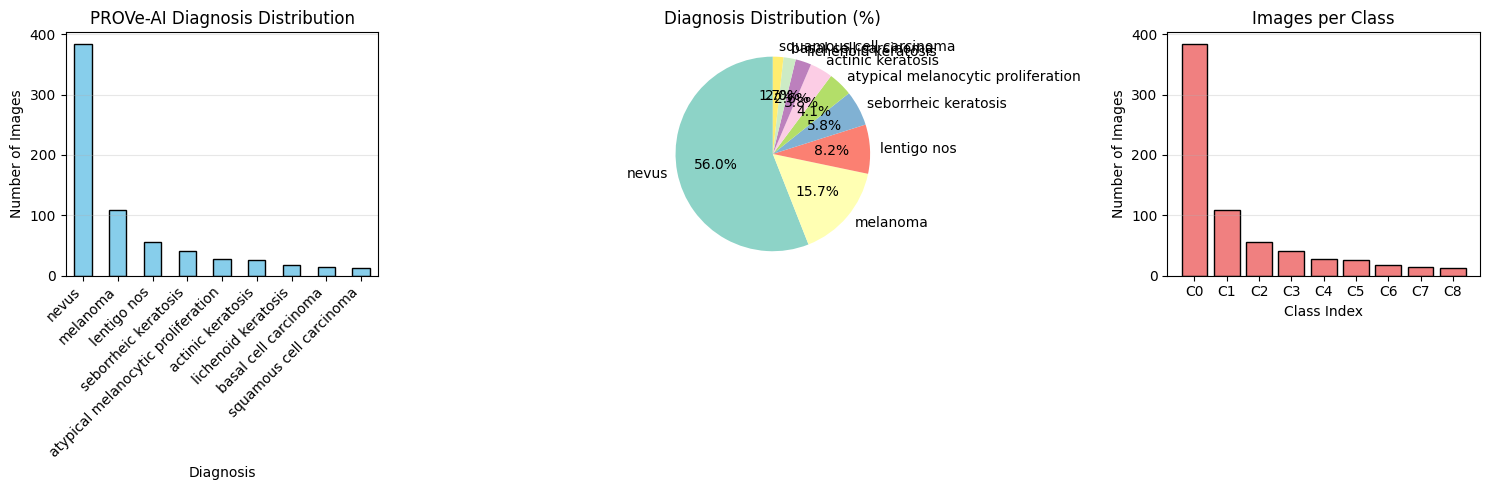


=== Visualizing PROVe-AI Sample Images ===
Found 9 unique diagnoses


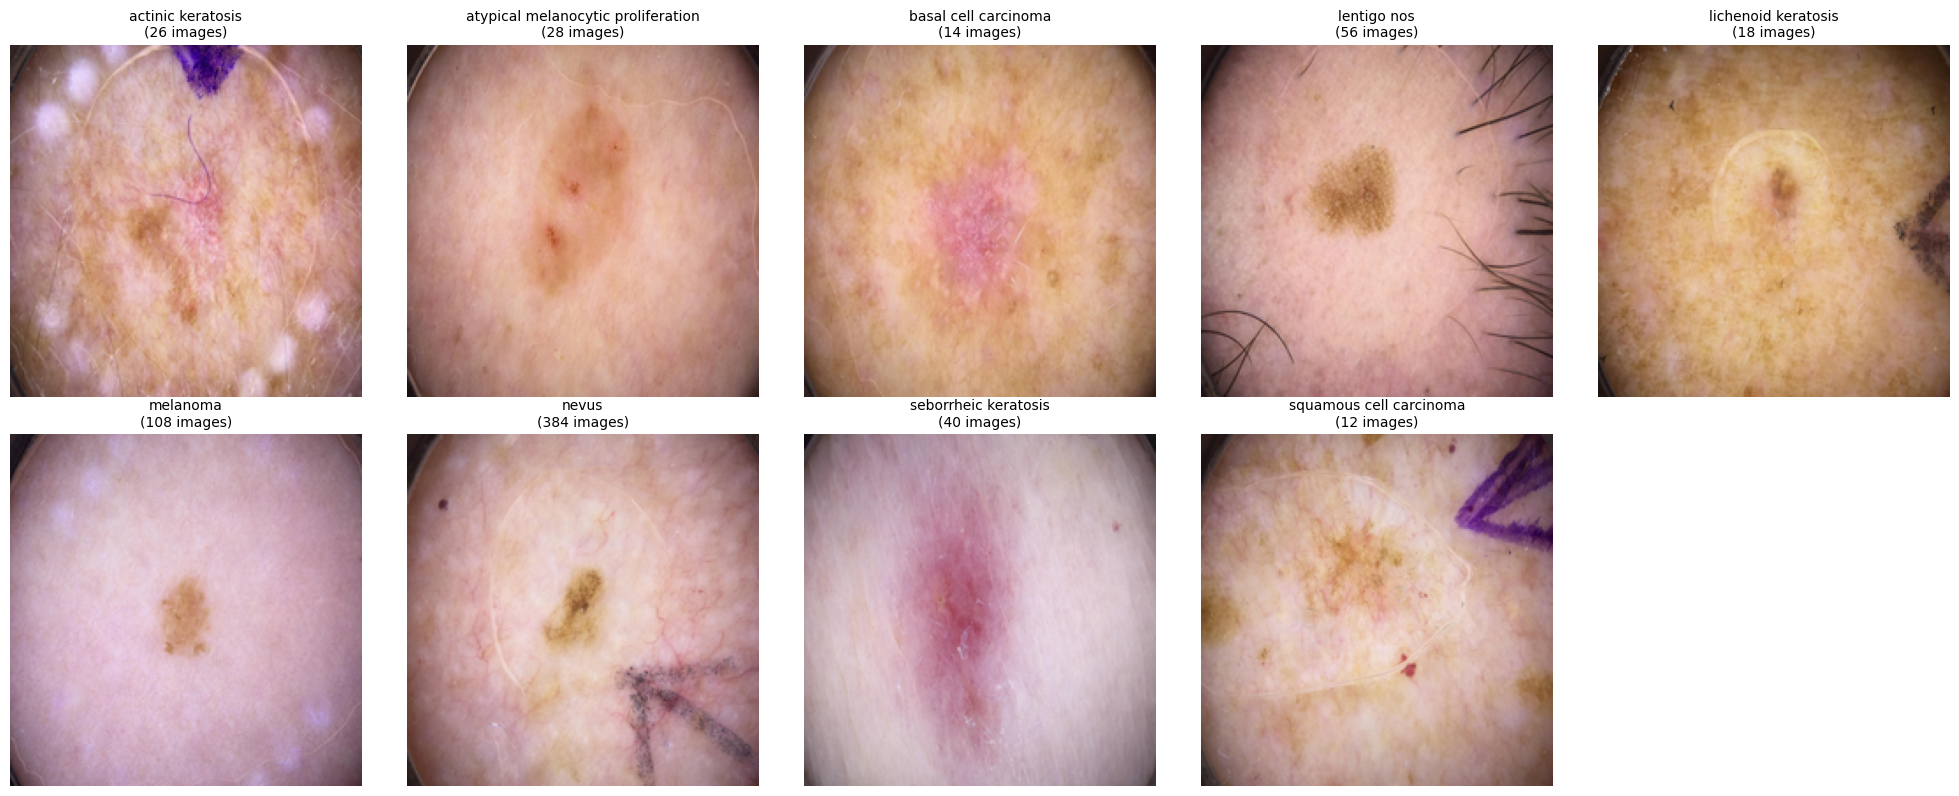


=== Creating Balanced PROVe-AI Dataset ===
Target count per class: 384
Augmented images will be saved to: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\augmented data
Class nevus: 384 (no augmentation needed)
Creating 276 augmented samples for class melanoma...
Class melanoma: 108 -> 384 (+276)
Creating 328 augmented samples for class lentigo nos...
Class lentigo nos: 56 -> 384 (+328)
Creating 344 augmented samples for class seborrheic keratosis...
Class seborrheic keratosis: 40 -> 384 (+344)
Creating 356 augmented samples for class atypical melanocytic proliferation...
Class atypical melanocytic proliferation: 28 -> 384 (+356)
Creating 358 augmented samples for class actinic keratosis...
Class actinic keratosis: 26 -> 384 (+358)
Creating 366 augmented samples for class lichenoid keratosis...
Class lichenoid keratosis: 18 -> 384 (+366)
Creating 370 augmented samples for class bas

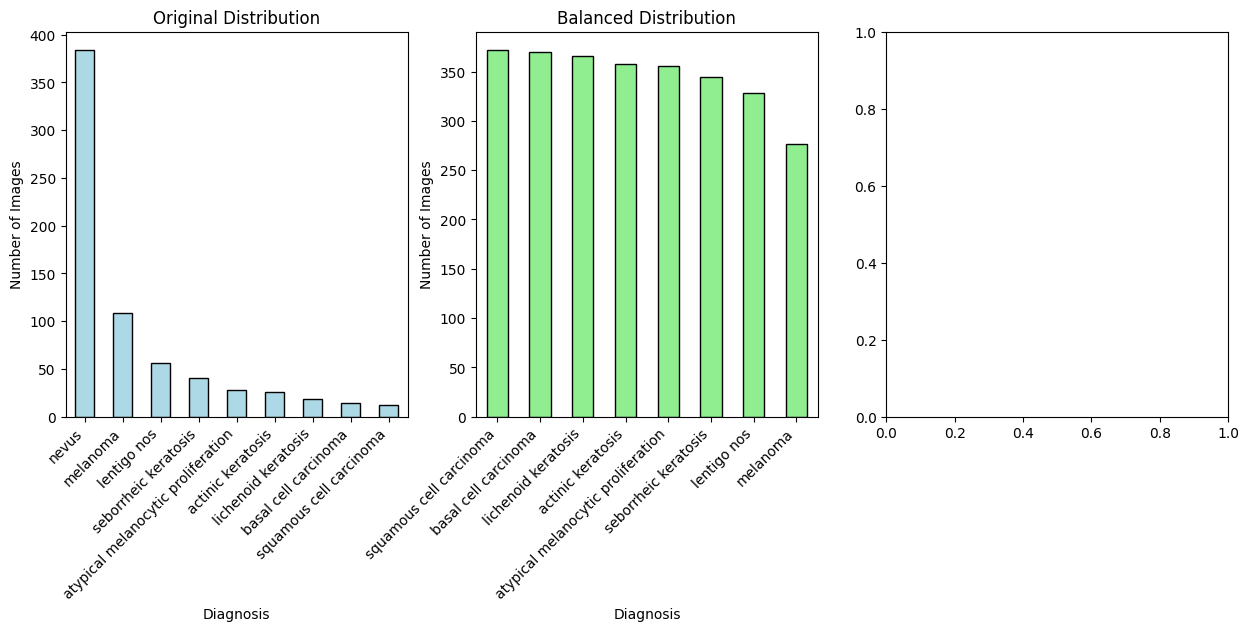

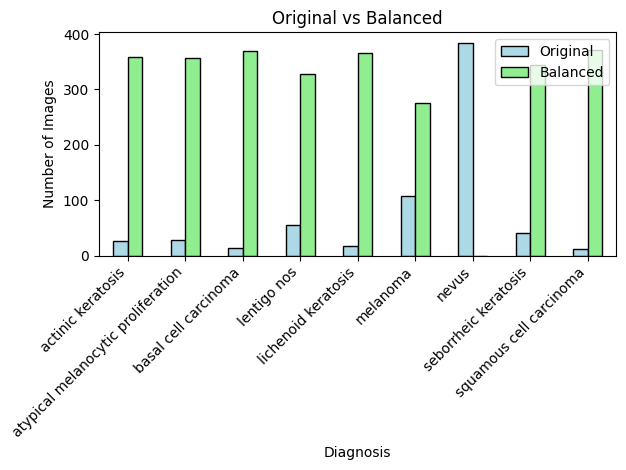


=== Preparing Data for Training ===
X shape: (2770, 224, 224, 3)
y shape: (2770,)
Unique labels: [0 1 2 3 4 5 7 8]
Label distribution: [358 356 370 328 366 276   0 344 372]
Training set: 2216 samples
Test set: 554 samples

PROVe-AI DATASET PREPARATION COMPLETE!
Original dataset: 686 samples
Balanced dataset: 2770 samples
Number of classes: 9
Training samples: 2216
Test samples: 554
Image size: 224x224
Augmented images saved to: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\augmented data
Ready for model training!
Dataset information saved to: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\augmented data
Augmentation report saved to: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI

True


=== Showing Augmented Image Examples ===


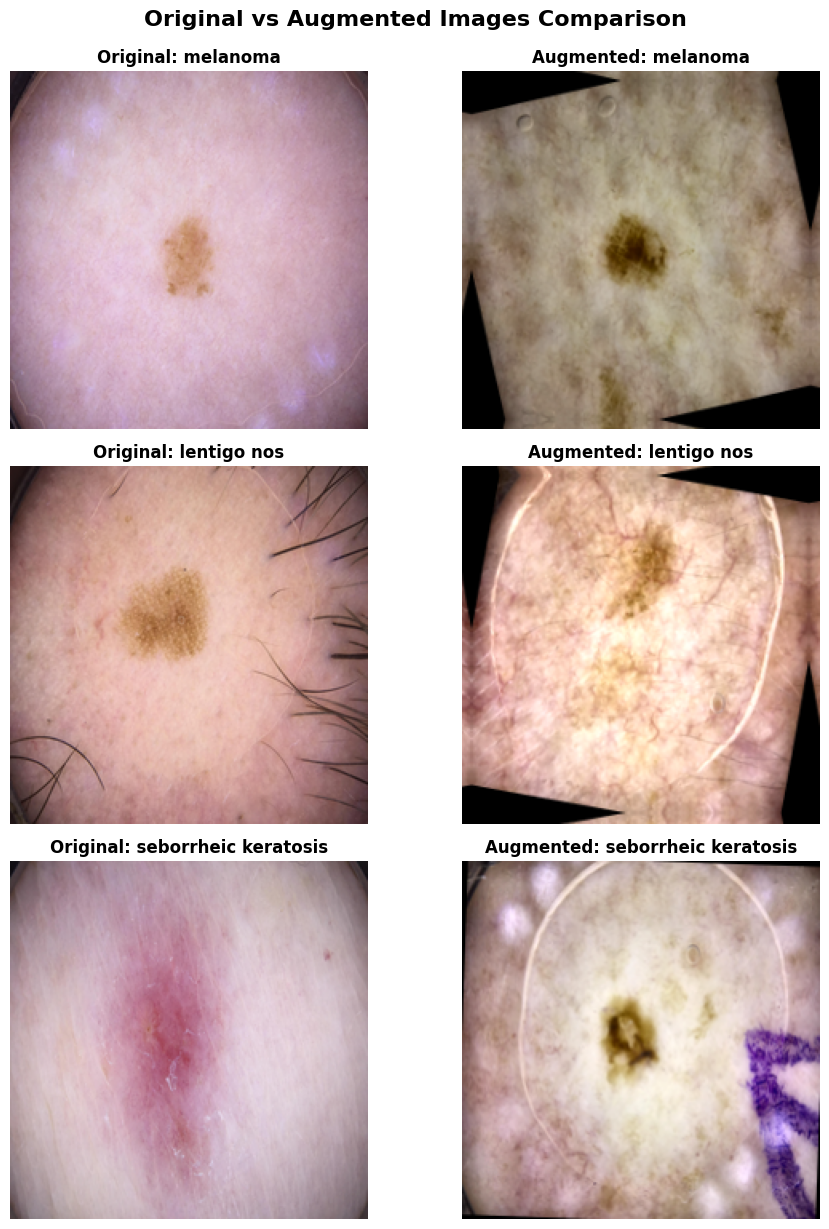

Showing 3 augmented examples

=== Training Data Summary ===
Your data is now ready for model training!
--------------------------------------------------
Training samples: (2216, 224, 224, 3)
Test samples: (554, 224, 224, 3)
Number of classes: 9
Class mappings: {'actinic keratosis': 0, 'atypical melanocytic proliferation': 1, 'basal cell carcinoma': 2, 'lentigo nos': 3, 'lichenoid keratosis': 4, 'melanoma': 5, 'nevus': 6, 'seborrheic keratosis': 7, 'squamous cell carcinoma': 8}

To use this data for training:
1. X_train = results['X_train']
2. y_train = results['y_train']
3. X_test = results['X_test']
4. y_test = results['y_test']
5. train_datagen = results['train_datagen']

PIPELINE COMPLETED SUCCESSFULLY!
Next steps:
1. Use the returned 'results' dictionary for model training
2. Check the augmented images in the output directory
3. Review the generated reports for dataset statistics
4. Use results['X_train'], results['X_test'] for model training
5. Use results['diagnosis_mapping'] fo

In [14]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import warnings
import time
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# Optional imports for enhanced features
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
    print("OpenCV not available. Some image processing features will be limited.")

# Configuration
class Config:
    """Configuration settings for the PROVe-AI classification pipeline"""
    # Image settings
    IMAGE_SIZE = 224  # Standard size for medical images
    BATCH_SIZE = 16   # Reduced batch size for stability
    EPOCHS = 100      # Training epochs
    
    # Model settings
    LEARNING_RATE = 0.0001  # Learning rate
    DROPOUT_RATE = 0.5      # Dropout rate
    
    # Training settings
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2
    PATIENCE = 3
    
    # Augmentation settings
    SAVE_AUGMENTED = True
    AUGMENTED_DIR = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\augmented data"

config = Config()

def load_prove_ai_organized_dataset(base_dir):
    """Load and explore the organized PROVe-AI dataset structure"""
    print("=== Loading Organized PROVe-AI Dataset ===")
    print(f"Base directory: {base_dir}")
    
    # Check if base directory exists
    if not os.path.exists(base_dir):
        print(f"ERROR: Base directory does not exist: {base_dir}")
        return None
    
    # Check for sorted images folder first
    sorted_images_dir = os.path.join(base_dir, "sorted images")
    if os.path.exists(sorted_images_dir):
        print(f"Found 'sorted images' folder: {sorted_images_dir}")
        search_dir = sorted_images_dir
    else:
        print(f"No 'sorted images' folder found, searching in base directory: {base_dir}")
        search_dir = base_dir
    
    # Look for class folders
    class_folders = [d for d in os.listdir(search_dir) 
                    if os.path.isdir(os.path.join(search_dir, d))]
    
    if not class_folders:
        print("No class folders found. Trying to load from image files...")
        return create_basic_dataframe_from_images(search_dir)
    
    print(f"Found class folders: {class_folders}")
    
    # Create DataFrame from organized structure
    data_list = []
    for class_name in class_folders:
        class_path = os.path.join(search_dir, class_name)
        
        # Find all images in this class folder
        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.JPG', '*.JPEG', '*.PNG']
        class_images = []
        
        for ext in image_extensions:
            class_images.extend(glob(os.path.join(class_path, ext)))
        
        print(f"Class '{class_name}': {len(class_images)} images")
        
        # Add to data list
        for img_path in class_images:
            img_name = os.path.splitext(os.path.basename(img_path))[0]
            data_list.append({
                'image_id': img_name,
                'diagnosis': class_name,
                'image_path': img_path
            })
    
    df = pd.DataFrame(data_list)
    print(f"Created DataFrame with {len(df)} images and {len(class_folders)} classes")
    return df

def load_prove_ai_from_csv(base_dir):
    """Load PROVe-AI dataset from CSV metadata file"""
    print("=== Loading PROVe-AI Dataset from CSV ===")
    
    # Look for CSV files
    csv_files = glob(os.path.join(base_dir, "*.csv"))
    if not csv_files:
        print("No CSV metadata file found.")
        return None
    
    print(f"Found CSV files: {csv_files}")
    
    # Load the first CSV file
    df = pd.read_csv(csv_files[0])
    print(f"Loaded CSV with {len(df)} rows and {df.shape[1]} columns")
    print(f"Columns: {list(df.columns)}")
    
    # Try to find image paths
    sorted_images_dir = os.path.join(base_dir, "sorted images")
    if os.path.exists(sorted_images_dir):
        # Find image ID column
        image_id_cols = ['image_id', 'id', 'filename', 'image_name', 'image', 'img_id', 'file', 'isic_id']
        id_col = None
        
        for col in image_id_cols:
            if col in df.columns:
                id_col = col
                break
        
        if id_col:
            df['image_path'] = df[id_col].apply(lambda x: find_image_path_prove_ai(x, sorted_images_dir))
        else:
            print("Warning: No image ID column found, using first column")
            df['image_path'] = df.iloc[:, 0].apply(lambda x: find_image_path_prove_ai(x, sorted_images_dir))
    
    return df

def find_image_path_prove_ai(image_id, images_dir):
    """Find image path for PROVe-AI dataset"""
    image_extensions = ['jpg', 'jpeg', 'png', 'bmp', 'tiff', 'JPG', 'JPEG', 'PNG']
    
    for ext in image_extensions:
        # Try different formats
        possible_names = [
            f"{image_id}.{ext}",
            f"{str(image_id).zfill(6)}.{ext}",
            f"{str(image_id).zfill(8)}.{ext}"
        ]
        
        for name in possible_names:
            # Search in all subdirectories
            matches = glob(os.path.join(images_dir, "**", name), recursive=True)
            if matches:
                return matches[0]
    
    return None

def create_basic_dataframe_from_images(base_dir):
    """Create a basic DataFrame from image files if no organized structure"""
    # Look for image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.JPG', '*.JPEG', '*.PNG']
    all_images = []
    
    for ext in image_extensions:
        all_images.extend(glob(os.path.join(base_dir, ext)))
        all_images.extend(glob(os.path.join(base_dir, "**", ext), recursive=True))
    
    if not all_images:
        print("No images found!")
        return None
    
    # Create basic DataFrame
    data_list = []
    for img_path in all_images:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        
        # Try to infer diagnosis from folder structure
        parent_dir = os.path.basename(os.path.dirname(img_path))
        if parent_dir not in ["sorted images", os.path.basename(base_dir)]:
            diagnosis = parent_dir
        else:
            diagnosis = 'unknown'
        
        data_list.append({
            'image_id': img_name,
            'diagnosis': diagnosis,
            'image_path': img_path
        })
    
    df = pd.DataFrame(data_list)
    print(f"Created DataFrame with {len(df)} images")
    return df

def preprocess_prove_ai_data(df):
    """Preprocess the PROVe-AI dataset"""
    print("\n=== Preprocessing PROVe-AI Data ===")
    
    if df is None:
        return None, None
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    print(f"Initial dataset shape: {df.shape}")
    print(f"Available columns: {list(df.columns)}")
    
    # Handle diagnosis column
    if 'diagnosis' not in df.columns:
        potential_cols = [col for col in df.columns if any(term in col.lower() for term in 
                         ['diagnosis', 'label', 'class', 'condition', 'disease', 'lesion_type', 'target'])]
        if potential_cols:
            print(f"Using '{potential_cols[0]}' as diagnosis column")
            df['diagnosis'] = df[potential_cols[0]]
        else:
            print("No diagnosis column found. Creating dummy diagnosis...")
            df['diagnosis'] = 'unknown'
    
    # Drop rows with missing diagnosis
    initial_count = len(df)
    df.dropna(subset=['diagnosis'], inplace=True)
    print(f"Removed {initial_count - len(df)} rows with missing diagnosis")
    
    # Clean diagnosis labels
    df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.lower()
    
    # Encode 'diagnosis' to numeric labels
    diagnosis_mapping = {label: idx for idx, label in enumerate(df['diagnosis'].unique())}
    df['diagnosis_label'] = df['diagnosis'].map(diagnosis_mapping)
    
    print(f"Diagnosis mapping: {diagnosis_mapping}")
    
    # Check if image paths exist
    if 'image_path' in df.columns:
        existing_paths = df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) and x is not None else False)
        valid_count = existing_paths.sum()
        print(f"Found {valid_count}/{len(df)} valid image paths")
        
        if valid_count == 0:
            print("WARNING: No valid image paths found!")
            return None, None
        
        # Keep only rows with valid image paths
        df = df[existing_paths].copy()
    
    print(f"Final dataset: {len(df)} samples with {len(df['diagnosis'].unique())} unique diagnoses")
    
    return df, diagnosis_mapping

def enhanced_load_image_pixels(image_path, target_size=224):
    """Load and preprocess image with proper medical image handling"""
    if not image_path or not os.path.exists(image_path):
        return None
    
    try:
        # Load image
        image = Image.open(image_path)
        
        # Convert to RGB if needed
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Resize to target size with high-quality resampling
        image = image.resize((target_size, target_size), Image.LANCZOS)
        
        # Convert to numpy array
        img_array = np.asarray(image)
        
        # Optional: Apply basic preprocessing for medical images
        if CV2_AVAILABLE:
            img_array = enhance_medical_image(img_array)
        
        return img_array
        
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def enhance_medical_image(image):
    """Apply medical-specific image enhancement"""
    if not CV2_AVAILABLE:
        return image
    
    # Convert to LAB color space for better contrast enhancement
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    
    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    
    # Convert back to RGB
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    return enhanced

def save_augmented_image(image_array, original_path, augmented_dir, class_name, aug_suffix):
    """Save an augmented image to the specified directory"""
    if not config.SAVE_AUGMENTED:
        return None
    
    # Create class directory if it doesn't exist
    class_dir = os.path.join(augmented_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)
    
    # Generate new filename
    original_name = os.path.splitext(os.path.basename(original_path))[0]
    new_filename = f"{original_name}_{aug_suffix}.jpg"
    new_path = os.path.join(class_dir, new_filename)
    
    # Convert and save image
    try:
        img = Image.fromarray(image_array.astype(np.uint8))
        img.save(new_path, 'JPEG', quality=95)
        return new_path
    except Exception as e:
        print(f"Error saving augmented image: {e}")
        return None

def analyze_dataset_distribution(df, dataset_name="PROVe-AI"):
    """Analyze and visualize the dataset distribution"""
    print(f"\n=== {dataset_name} Dataset Analysis ===")
    
    if df is None or len(df) == 0:
        print("No data to analyze")
        return
    
    # Class distribution
    class_counts = df['diagnosis'].value_counts()
    print("Class distribution:")
    for diagnosis, count in class_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {diagnosis}: {count} images ({percentage:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Bar plot
    plt.subplot(1, 3, 1)
    class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'{dataset_name} Diagnosis Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Pie chart
    plt.subplot(1, 3, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    plt.title('Diagnosis Distribution (%)')
    
    # Class comparison
    plt.subplot(1, 3, 3)
    plt.bar(range(len(class_counts)), class_counts.values, color='lightcoral', edgecolor='black')
    plt.title('Images per Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_counts)), [f"C{i}" for i in range(len(class_counts))])
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

def create_balanced_dataset_smart(data):
    """Create balanced dataset using smart augmentation for PROVe-AI"""
    print("\n=== Creating Balanced PROVe-AI Dataset ===")
    
    class_counts = data['diagnosis'].value_counts()
    
    # Check if we have only one class
    if len(class_counts) == 1:
        print("Only one class found. No balancing needed.")
        return data
    
    max_count = class_counts.max()
    
    print(f"Target count per class: {max_count}")
    
    # Create augmented data directory
    if config.SAVE_AUGMENTED:
        os.makedirs(config.AUGMENTED_DIR, exist_ok=True)
        print(f"Augmented images will be saved to: {config.AUGMENTED_DIR}")
    
    balanced_frames = []
    
    for dx in class_counts.index:
        class_data = data[data['diagnosis'] == dx].copy()
        current_count = len(class_data)
        
        if current_count < max_count:
            # Calculate how many more samples we need
            needed = max_count - current_count
            
            # Use smart sampling instead of simple duplication
            additional_samples = create_additional_samples_prove_ai(class_data, needed, dx)
            balanced_frames.append(pd.concat([class_data, additional_samples], ignore_index=True))
            
            print(f"Class {dx}: {current_count} -> {len(balanced_frames[-1])} (+{needed})")
        else:
            balanced_frames.append(class_data)
            print(f"Class {dx}: {current_count} (no augmentation needed)")
    
    # Combine all balanced data
    balanced_data = pd.concat(balanced_frames, ignore_index=True)
    
    print(f"\nFinal balanced dataset: {len(balanced_data)} images")
    
    return balanced_data

def create_additional_samples_prove_ai(class_data, needed_count, class_name):
    """Create additional samples using intelligent duplication with variation"""
    additional_samples = []
    
    print(f"Creating {needed_count} augmented samples for class {class_name}...")
    
    # Sample with replacement but add some variation
    for i in range(needed_count):
        # Select a random sample from the class
        sample_idx = np.random.randint(0, len(class_data))
        sample = class_data.iloc[sample_idx].copy()
        
        # Add slight variation to avoid exact duplicates
        if 'image_path' in sample:
            # Load and augment the image
            img_array = enhanced_load_image_pixels(sample['image_path'], config.IMAGE_SIZE)
            if img_array is not None:
                # Apply random augmentation to the image
                augmented_image = apply_random_augmentation(img_array)
                
                # Save augmented image if requested
                if config.SAVE_AUGMENTED:
                    aug_suffix = f"aug_{i:04d}"
                    new_path = save_augmented_image(augmented_image, sample['image_path'], 
                                                  config.AUGMENTED_DIR, class_name, aug_suffix)
                    if new_path:
                        sample['image_path'] = new_path
                
                # Store the augmented image array
                sample['image_pixel'] = augmented_image
                
                # Update image_id to avoid conflicts
                if 'image_id' in sample:
                    sample['image_id'] = f"{sample['image_id']}_aug_{i:04d}"
        
        additional_samples.append(sample)
    
    return pd.DataFrame(additional_samples)

def apply_random_augmentation(image):
    """Apply random augmentation to an image for PROVe-AI"""
    if not CV2_AVAILABLE:
        # Basic augmentation without OpenCV
        if np.random.random() > 0.5:
            image = np.fliplr(image)  # Horizontal flip
        return image
    
    # Random rotation (-15 to 15 degrees)
    angle = np.random.uniform(-15, 15)
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (width, height))
    
    # Random brightness adjustment
    brightness = np.random.uniform(0.8, 1.2)
    brightened = np.clip(rotated * brightness, 0, 255).astype(np.uint8)
    
    # Random horizontal flip
    if np.random.random() > 0.5:
        brightened = cv2.flip(brightened, 1)
    
    # Random zoom (slight)
    zoom_factor = np.random.uniform(0.9, 1.1)
    if zoom_factor != 1.0:
        h, w = brightened.shape[:2]
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
        if new_h > 0 and new_w > 0:
            resized = cv2.resize(brightened, (new_w, new_h))
            # Crop or pad to original size
            if zoom_factor > 1.0:
                start_h = (new_h - h) // 2
                start_w = (new_w - w) // 2
                brightened = resized[start_h:start_h+h, start_w:start_w+w]
            else:
                pad_h = (h - new_h) // 2
                pad_w = (w - new_w) // 2
                brightened = cv2.copyMakeBorder(resized, pad_h, h-new_h-pad_h, 
                                              pad_w, w-new_w-pad_w, cv2.BORDER_REFLECT)
    
    return brightened

def load_image_pixels_for_dataset(data):
    """Load image pixels for the entire dataset"""
    print(f"\n=== Loading Image Pixels ===")
    print(f"Loading images at {config.IMAGE_SIZE}x{config.IMAGE_SIZE} resolution...")
    
    # Load image pixels for samples that don't already have them
    def load_pixel_data(row):
        if 'image_pixel' in row and row['image_pixel'] is not None:
            return row['image_pixel']  # Already loaded (from augmentation)
        else:
            return enhanced_load_image_pixels(row['image_path'], config.IMAGE_SIZE)
    
    data['image_pixel'] = data.apply(load_pixel_data, axis=1)
    
    # Remove rows with failed image loading
    initial_count = len(data)
    data = data[data['image_pixel'].notnull()]
    final_count = len(data)
    print(f"Successfully loaded {final_count}/{initial_count} images")
    
    if final_count == 0:
        print("ERROR: No images could be loaded successfully!")
        return None
    
    return data

def prepare_data_for_training(data):
    """Prepare data for model training"""
    print("\n=== Preparing Data for Training ===")
    
    # Convert image pixels to numpy array
    X = np.stack(data['image_pixel'].values)
    y = np.array(data['diagnosis_label'].values)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Unique labels: {np.unique(y)}")
    print(f"Label distribution: {np.bincount(y)}")
    
    # Check if we have enough samples for splitting
    if len(X) < 10:
        print("WARNING: Very few samples. Consider using all data for training.")
        test_size = 0.1
    else:
        test_size = config.TEST_SPLIT
    
    # Split data with stratification (if possible)
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
    except ValueError:
        # If stratification fails (e.g., too few samples per class)
        print("Warning: Stratification failed, using random split")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    
    # Normalize data manually
    X_train = X_train.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0
    
    # Create simple data generators with minimal augmentation
    train_datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        horizontal_flip=True,
        validation_split=config.VALIDATION_SPLIT
    )
    
    # Fit the generator
    train_datagen.fit(X_train)
    
    return X_train, X_test, y_train, y_test, train_datagen

def visualize_sample_images(df, max_samples_per_class=1, dataset_name="PROVe-AI"):
    """Visualize sample images for each diagnosis"""
    print(f"\n=== Visualizing {dataset_name} Sample Images ===")
    
    if df is None or len(df) == 0:
        print("No data to visualize")
        return
    
    unique_diagnoses = df['diagnosis'].unique()
    n_diagnoses = len(unique_diagnoses)
    
    print(f"Found {n_diagnoses} unique diagnoses")
    
    # Calculate grid size
    cols = min(5, n_diagnoses)
    rows = (n_diagnoses + cols - 1) // cols
    
    plt.figure(figsize=(4*cols, 4*rows))
    
    for i, diagnosis in enumerate(unique_diagnoses):
        # Get samples for this diagnosis
        diagnosis_samples = df[df['diagnosis'] == diagnosis]
        
        if len(diagnosis_samples) == 0:
            continue
        
        # Take first sample
        sample_image = diagnosis_samples.iloc[0]
        img_path = sample_image['image_path']
        
        try:
            # Load and display image
            img = Image.open(img_path)
            
            # Convert to RGB if necessary
            if img.mode != 'RGB':
                img = img.convert('RGB')
            
            # Resize for consistent display
            img = img.resize((200, 200), Image.LANCZOS)
            
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
            plt.axis("off")
            
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            plt.subplot(rows, cols, i + 1)
            plt.text(0.5, 0.5, f"Error loading\n{diagnosis}", 
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
            plt.axis("off")
    
    plt.tight_layout()
    plt.show()

def visualize_augmented_samples(balanced_data, original_data):
    """Visualize original vs augmented samples"""
    print("\n=== Visualizing Augmentation Results ===")
    
    # Compare class distributions
    plt.figure(figsize=(15, 5))
    
    # Original distribution
    plt.subplot(1, 3, 1)
    original_counts = original_data['diagnosis'].value_counts()
    original_counts.plot(kind='bar', color='lightblue', edgecolor='black')
    plt.title('Original Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    
    # Balanced distribution
    plt.subplot(1, 3, 2)
    balanced_counts = balanced_data['diagnosis'].value_counts()
    balanced_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title('Balanced Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    
    # Comparison
    plt.subplot(1, 3, 3)
    comparison_df = pd.DataFrame({
        'Original': original_counts,
        'Balanced': balanced_counts
    }).fillna(0)
    comparison_df.plot(kind='bar', color=['lightblue', 'lightgreen'], edgecolor='black')
    plt.title('Original vs Balanced')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def generate_dataset_summary(df, dataset_name="PROVe-AI"):
    """Generate a comprehensive dataset summary"""
    print(f"\n=== {dataset_name} Dataset Summary ===")
    
    if df is None:
        print("No dataset loaded")
        return
    
    print(f"Total samples: {len(df)}")
    print(f"Total unique diagnoses: {len(df['diagnosis'].unique())}")
    print(f"Columns: {list(df.columns)}")
    
    # Missing values
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("\nMissing values:")
        for col, missing_count in missing_data.items():
            if missing_count > 0:
                print(f"  {col}: {missing_count}")
    else:
        print("\nNo missing values found")
    
    # Class balance analysis
    if 'diagnosis' in df.columns:
        class_counts = df['diagnosis'].value_counts()
        min_class = class_counts.min()
        max_class = class_counts.max()
        balance_ratio = min_class / max_class
        print(f"\nClass balance:")
        print(f"  Most common class: {max_class} samples")
        print(f"  Least common class: {min_class} samples")
        print(f"  Balance ratio (min/max): {balance_ratio:.3f}")

def save_dataset_info(results, save_path=None):
    """Save dataset information and mappings"""
    if results is None:
        return
    
    if save_path is None:
        save_path = config.AUGMENTED_DIR
    
    os.makedirs(save_path, exist_ok=True)
    
    # Save diagnosis mapping
    mapping_file = os.path.join(save_path, "diagnosis_mapping.txt")
    with open(mapping_file, 'w') as f:
        f.write("PROVe-AI Diagnosis Mapping:\n")
        f.write("=" * 30 + "\n")
        for diagnosis, label in results['diagnosis_mapping'].items():
            f.write(f"{label}: {diagnosis}\n")
    
    # Save dataset statistics
    stats_file = os.path.join(save_path, "dataset_statistics.txt")
    with open(stats_file, 'w') as f:
        f.write("PROVe-AI Dataset Statistics:\n")
        f.write("=" * 35 + "\n")
        f.write(f"Original dataset size: {len(results['original_data'])}\n")
        f.write(f"Balanced dataset size: {len(results['balanced_data'])}\n")
        f.write(f"Number of classes: {len(results['diagnosis_mapping'])}\n")
        f.write(f"Training samples: {len(results['X_train'])}\n")
        f.write(f"Test samples: {len(results['X_test'])}\n")
        f.write(f"Image size: {results['config'].IMAGE_SIZE}x{results['config'].IMAGE_SIZE}\n")
        
        f.write("\nClass distribution (balanced):\n")
        balanced_counts = results['balanced_data']['diagnosis'].value_counts()
        for diagnosis, count in balanced_counts.items():
            f.write(f"  {diagnosis}: {count} images\n")
    
    print(f"Dataset information saved to: {save_path}")

def create_augmentation_report(original_data, balanced_data, save_path=None):
    """Create a detailed augmentation report with fixed KeyError handling"""
    if save_path is None:
        save_path = config.AUGMENTED_DIR
    
    os.makedirs(save_path, exist_ok=True)
    
    report_file = os.path.join(save_path, "augmentation_report.txt")
    
    with open(report_file, 'w') as f:
        f.write("PROVe-AI Data Augmentation Report\n")
        f.write("=" * 40 + "\n\n")
        
        original_counts = original_data['diagnosis'].value_counts()
        balanced_counts = balanced_data['diagnosis'].value_counts()
        
        f.write("Original vs Balanced Dataset:\n")
        f.write("-" * 30 + "\n")
        f.write(f"{'Class':<15} {'Original':<10} {'Balanced':<10} {'Added':<8}\n")
        f.write("-" * 45 + "\n")
        
        total_original = 0
        total_balanced = 0
        total_added = 0
        
        # Get all unique classes from both datasets
        all_classes = set(original_counts.index) | set(balanced_counts.index)
        
        for diagnosis in sorted(all_classes):
            orig_count = original_counts.get(diagnosis, 0)
            bal_count = balanced_counts.get(diagnosis, 0)
            added = bal_count - orig_count
            
            f.write(f"{diagnosis:<15} {orig_count:<10} {bal_count:<10} {added:<8}\n")
            
            total_original += orig_count
            total_balanced += bal_count
            total_added += added
        
        f.write("-" * 45 + "\n")
        f.write(f"{'TOTAL':<15} {total_original:<10} {total_balanced:<10} {total_added:<8}\n")
        
        f.write(f"\nAugmentation Summary:\n")
        f.write(f"- Original dataset: {total_original} images\n")
        f.write(f"- Balanced dataset: {total_balanced} images\n")
        f.write(f"- Augmented images created: {total_added}\n")
        if total_original > 0:
            f.write(f"- Augmentation ratio: {total_added/total_original:.2f}x\n")
        else:
            f.write(f"- Augmentation ratio: N/A\n")
        
        f.write(f"\nClass Distribution Analysis:\n")
        f.write(f"- Number of classes: {len(all_classes)}\n")
        f.write(f"- Classes in original: {list(original_counts.index)}\n")
        f.write(f"- Classes in balanced: {list(balanced_counts.index)}\n")
        
        f.write(f"\nAugmentation Techniques Applied:\n")
        f.write("- Random rotation (-15° to +15°)\n")
        f.write("- Random brightness adjustment (0.8x to 1.2x)\n")
        f.write("- Random horizontal flipping\n")
        f.write("- Random zoom (0.9x to 1.1x)\n")
        if CV2_AVAILABLE:
            f.write("- CLAHE contrast enhancement\n")
        
        f.write(f"\nOutput Directory: {config.AUGMENTED_DIR}\n")
    
    print(f"Augmentation report saved to: {report_file}")

def show_augmented_examples(results, num_examples=3):
    """Show examples of original vs augmented images with improved error handling"""
    print("\n=== Showing Augmented Image Examples ===")
    
    if results is None:
        print("No results to show")
        return
    
    balanced_data = results['balanced_data']
    original_data = results['original_data']
    
    # Find augmented samples (those with 'aug_' in image_id)
    if 'image_id' in balanced_data.columns:
        augmented_samples = balanced_data[balanced_data['image_id'].str.contains('aug_', na=False)]
    else:
        print("No image_id column found, showing random augmented vs original examples")
        # If no image_id, just show some examples from balanced vs original
        augmented_samples = balanced_data.sample(min(num_examples, len(balanced_data)))
    
    if len(augmented_samples) == 0:
        print("No augmented samples found")
        return
    
    # Get unique classes that have augmented samples
    augmented_classes = augmented_samples['diagnosis'].unique()[:num_examples]
    
    fig, axes = plt.subplots(len(augmented_classes), 2, figsize=(10, 4*len(augmented_classes)))
    if len(augmented_classes) == 1:
        axes = axes.reshape(1, -1)
    
    for i, class_name in enumerate(augmented_classes):
        # Get augmented sample for this class
        class_aug_samples = augmented_samples[augmented_samples['diagnosis'] == class_name]
        if len(class_aug_samples) == 0:
            continue
        
        aug_sample = class_aug_samples.iloc[0]
        
        # Find original sample from the same class
        original_class_samples = original_data[original_data['diagnosis'] == class_name]
        
        if len(original_class_samples) > 0:
            orig_sample = original_class_samples.iloc[0]
            
            # Load and display original image
            try:
                orig_img = Image.open(orig_sample['image_path'])
                if orig_img.mode != 'RGB':
                    orig_img = orig_img.convert('RGB')
                orig_img = orig_img.resize((224, 224), Image.LANCZOS)
                
                axes[i, 0].imshow(orig_img)
                axes[i, 0].set_title(f"Original: {class_name}", fontsize=12, fontweight='bold')
                axes[i, 0].axis('off')
                
            except Exception as e:
                print(f"Error loading original image for {class_name}: {e}")
                axes[i, 0].text(0.5, 0.5, f"Error loading\noriginal\n{class_name}", 
                               ha='center', va='center', transform=axes[i, 0].transAxes, 
                               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
                axes[i, 0].set_title(f"Original: {class_name}", fontsize=12, fontweight='bold')
                axes[i, 0].axis('off')
        else:
            # No original sample found
            axes[i, 0].text(0.5, 0.5, f"No original\nsample found\n{class_name}", 
                           ha='center', va='center', transform=axes[i, 0].transAxes,
                           fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
            axes[i, 0].set_title(f"Original: {class_name}", fontsize=12, fontweight='bold')
            axes[i, 0].axis('off')
        
        # Load and display augmented image
        try:
            # Check if image_pixel exists (for augmented samples)
            if 'image_pixel' in aug_sample and aug_sample['image_pixel'] is not None:
                # Use the pixel data directly
                aug_img_array = aug_sample['image_pixel']
                if isinstance(aug_img_array, np.ndarray):
                    axes[i, 1].imshow(aug_img_array.astype(np.uint8))
                else:
                    # Fallback to loading from path
                    aug_img = Image.open(aug_sample['image_path'])
                    if aug_img.mode != 'RGB':
                        aug_img = aug_img.convert('RGB')
                    aug_img = aug_img.resize((224, 224), Image.LANCZOS)
                    axes[i, 1].imshow(aug_img)
            else:
                # Load from path
                aug_img = Image.open(aug_sample['image_path'])
                if aug_img.mode != 'RGB':
                    aug_img = aug_img.convert('RGB')
                aug_img = aug_img.resize((224, 224), Image.LANCZOS)
                axes[i, 1].imshow(aug_img)
            
            axes[i, 1].set_title(f"Augmented: {class_name}", fontsize=12, fontweight='bold')
            axes[i, 1].axis('off')
            
        except Exception as e:
            print(f"Error loading augmented image for {class_name}: {e}")
            axes[i, 1].text(0.5, 0.5, f"Error loading\naugmented\n{class_name}", 
                           ha='center', va='center', transform=axes[i, 1].transAxes,
                           fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
            axes[i, 1].set_title(f"Augmented: {class_name}", fontsize=12, fontweight='bold')
            axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.suptitle("Original vs Augmented Images Comparison", fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    print(f"Showing {len(augmented_classes)} augmented examples")

def validate_augmented_directory():
    """Validate that augmented images were saved correctly"""
    print("\n=== Validating Augmented Directory ===")
    
    if not os.path.exists(config.AUGMENTED_DIR):
        print(f"Augmented directory does not exist: {config.AUGMENTED_DIR}")
        return False
    
    # Count images in each class folder
    class_folders = [d for d in os.listdir(config.AUGMENTED_DIR) 
                    if os.path.isdir(os.path.join(config.AUGMENTED_DIR, d))]
    
    if not class_folders:
        print("No class folders found in augmented directory")
        return False
    
    print(f"Found {len(class_folders)} class folders:")
    total_images = 0
    
    for class_folder in class_folders:
        class_path = os.path.join(config.AUGMENTED_DIR, class_folder)
        images = glob(os.path.join(class_path, "*.jpg"))
        print(f"  {class_folder}: {len(images)} images")
        total_images += len(images)
    
    print(f"Total augmented images saved: {total_images}")
    return True

def create_training_summary(results):
    """Create a summary ready for model training"""
    print("\n=== Training Data Summary ===")
    print("Your data is now ready for model training!")
    print("-" * 50)
    
    if results:
        print(f"Training samples: {results['X_train'].shape}")
        print(f"Test samples: {results['X_test'].shape}")
        print(f"Number of classes: {len(results['diagnosis_mapping'])}")
        print(f"Class mappings: {results['diagnosis_mapping']}")
        
        print("\nTo use this data for training:")
        print("1. X_train = results['X_train']")
        print("2. y_train = results['y_train']") 
        print("3. X_test = results['X_test']")
        print("4. y_test = results['y_test']")
        print("5. train_datagen = results['train_datagen']")

def main():
    """Main function to run the PROVe-AI dataset pipeline with augmentation"""
    # Set the base directory for PROVe-AI dataset
    base_prove_ai_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset"
    
    print("=== PROVe-AI Dataset Pipeline with Data Augmentation ===")
    
    # Try to load from organized structure first, then from CSV
    df = load_prove_ai_organized_dataset(base_prove_ai_dir)
    
    if df is None:
        print("Trying to load from CSV...")
        df = load_prove_ai_from_csv(base_prove_ai_dir)
    
    if df is None:
        print("Failed to load dataset")
        return None
    
    # Preprocess data
    df, diagnosis_mapping = preprocess_prove_ai_data(df)
    
    if df is None or len(df) == 0:
        print("No valid data after preprocessing")
        return None
    
    # Generate summary
    generate_dataset_summary(df)
    
    # Analyze original distribution
    print("\n=== Original Dataset Analysis ===")
    original_class_counts = analyze_dataset_distribution(df)
    
    # Visualize original samples
    visualize_sample_images(df, max_samples_per_class=1)
    
    # Create balanced dataset with augmentation
    balanced_data = create_balanced_dataset_smart(df)
    
    # Load image pixels for the balanced dataset
    balanced_data = load_image_pixels_for_dataset(balanced_data)
    
    if balanced_data is None:
        print("Failed to load image pixels")
        return None
    
    # Visualize augmentation results
    visualize_augmented_samples(balanced_data, df)
    
    # Prepare data for training
    X_train, X_test, y_train, y_test, train_datagen = prepare_data_for_training(balanced_data)
    
    print("\n" + "="*60)
    print("PROVe-AI DATASET PREPARATION COMPLETE!")
    print("="*60)
    print(f"Original dataset: {len(df)} samples")
    print(f"Balanced dataset: {len(balanced_data)} samples")
    print(f"Number of classes: {len(diagnosis_mapping)}")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Image size: {config.IMAGE_SIZE}x{config.IMAGE_SIZE}")
    
    if config.SAVE_AUGMENTED:
        print(f"Augmented images saved to: {config.AUGMENTED_DIR}")
    
    print("Ready for model training!")
    
    return {
        'original_data': df,
        'balanced_data': balanced_data,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'train_datagen': train_datagen,
        'diagnosis_mapping': diagnosis_mapping,
        'config': config
    }

# Run the pipeline
if __name__ == "__main__":
    print("Starting PROVe-AI Dataset Pipeline...")
    results = main()
    
    if results is not None:
        # Save additional information
        save_dataset_info(results)
        create_augmentation_report(results['original_data'], results['balanced_data'])
        
        # Validate augmented directory
        validate_augmented_directory()
        
        # Show examples of augmented images
        show_augmented_examples(results)
        
        # Create training summary
        create_training_summary(results)
        
        print("\n" + "="*60)
        print("PIPELINE COMPLETED SUCCESSFULLY!")
        print("="*60)
        print("Next steps:")
        print("1. Use the returned 'results' dictionary for model training")
        print("2. Check the augmented images in the output directory")
        print("3. Review the generated reports for dataset statistics")
        print("4. Use results['X_train'], results['X_test'] for model training")
        print("5. Use results['diagnosis_mapping'] for class labels")
        
        print(f"\nGenerated files:")
        print(f"- Augmented images: {config.AUGMENTED_DIR}")
        print(f"- Diagnosis mapping: {config.AUGMENTED_DIR}/diagnosis_mapping.txt")
        print(f"- Dataset statistics: {config.AUGMENTED_DIR}/dataset_statistics.txt") 
        print(f"- Augmentation report: {config.AUGMENTED_DIR}/augmentation_report.txt")
        
    else:
        print("Pipeline failed. Please check the error messages above.")

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from datetime import datetime
import os
import gc

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten, 
                                   Dropout, GlobalAveragePooling2D, BatchNormalization,
                                   Input, Activation, MaxPool2D)
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

EPOCHS = 100

class PROVeAIModelTrainer:
    """Enhanced Model Trainer specifically designed for PROVe-AI dataset"""
    
    def __init__(self, balanced_data, diagnosis_mapping, config):
        self.balanced_data = balanced_data
        self.diagnosis_mapping = diagnosis_mapping
        self.config = config
        self.num_classes = len(diagnosis_mapping)
        
        # Create reverse mapping for class names
        self.reverse_mapping = {v: k for k, v in diagnosis_mapping.items()}
        self.class_names = [self.reverse_mapping[i] for i in range(self.num_classes)]
        
        # Initialize results storage
        self.models = {}
        self.histories = {}
        self.predictions = {}
        self.training_times = {}
        self.testing_times = {}
        self.model_summaries = {}
        self.test_accuracies = {}
        
        # Prepare data splits
        self.prepare_data_splits()
        
    def prepare_data_splits(self):
        """Prepare train/test splits for PROVe-AI dataset"""
        print("\n=== Preparing PROVe-AI Data Splits ===")
        
        # Check if we have enough samples for splitting
        if len(self.balanced_data) < 10:
            print("WARNING: Very few samples. Consider using all data for training.")
            test_size = 0.1
        else:
            test_size = self.config.TEST_SPLIT
        
        # Split data with stratification (if possible)
        try:
            self.train_data, self.test_data = train_test_split(
                self.balanced_data, 
                test_size=test_size, 
                random_state=42, 
                stratify=self.balanced_data['diagnosis_label']
            )
        except ValueError:
            print("Warning: Stratification failed, using random split")
            self.train_data, self.test_data = train_test_split(
                self.balanced_data, 
                test_size=test_size, 
                random_state=42
            )
        
        print(f"Training set: {len(self.train_data)} samples")
        print(f"Test set: {len(self.test_data)} samples")
        print(f"Number of classes: {self.num_classes}")
        print(f"Class names: {self.class_names}")
        
        # Calculate steps for generators
        self.train_steps = max(1, len(self.train_data) // self.config.BATCH_SIZE)
        self.val_data_size = max(1, int(len(self.train_data) * self.config.VALIDATION_SPLIT))
        self.val_steps = max(1, self.val_data_size // self.config.BATCH_SIZE)
        self.test_steps = max(1, len(self.test_data) // self.config.BATCH_SIZE)
        
        print(f"Steps per epoch - Train: {self.train_steps}, Val: {self.val_steps}, Test: {self.test_steps}")
    
    def create_custom_generator(self, data, batch_size=None, is_validation=False):
        """Custom generator that loads images on demand for PROVe-AI dataset"""
        if batch_size is None:
            batch_size = self.config.BATCH_SIZE
            
        while True:
            if is_validation:
                # For validation, use consistent sampling
                indices = np.arange(len(data))
            else:
                # For training, shuffle
                indices = np.random.permutation(len(data))
                
            for i in range(0, len(data), batch_size):
                batch_indices = indices[i:i+batch_size]
                batch_data = data.iloc[batch_indices]
                
                batch_x = []
                batch_y = []
                
                for _, row in batch_data.iterrows():
                    # Check if image_pixel exists (from augmentation) or load from path
                    if 'image_pixel' in row and row['image_pixel'] is not None:
                        img = row['image_pixel']
                    else:
                        img = enhanced_load_image_pixels(row['image_path'], self.config.IMAGE_SIZE)
                    
                    if img is not None:
                        batch_x.append(img)
                        batch_y.append(row['diagnosis_label'])
                
                if len(batch_x) > 0:
                    batch_x = np.array(batch_x).astype(np.float32) / 255.0
                    batch_y = np.array(batch_y)
                    yield batch_x, batch_y
    
    def create_custom_cnn(self):
        """Create custom CNN with dynamic number of classes for PROVe-AI"""
        model = Sequential([
            Conv2D(32, (3, 3), activation='relu', input_shape=(self.config.IMAGE_SIZE, self.config.IMAGE_SIZE, 3)),
            BatchNormalization(),
            MaxPool2D(2, 2),
            
            Conv2D(64, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPool2D(2, 2),
            
            Conv2D(128, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPool2D(2, 2),
            
            Conv2D(256, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPool2D(2, 2),
            
            GlobalAveragePooling2D(),
            Dropout(self.config.DROPOUT_RATE),
            Dense(256, activation='relu'),
            Dropout(self.config.DROPOUT_RATE),
            Dense(self.num_classes, activation='softmax')
        ])
        return model

    def create_resnet50(self):
        """Create ResNet50 with dynamic number of classes for PROVe-AI"""
        base_model = ResNet50(
            weights='imagenet', 
            include_top=False, 
            input_shape=(self.config.IMAGE_SIZE, self.config.IMAGE_SIZE, 3)
        )
        
        # Fine-tune last 10 layers
        for layer in base_model.layers[:-10]:
            layer.trainable = False
        for layer in base_model.layers[-10:]:
            layer.trainable = True
            
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            Dropout(self.config.DROPOUT_RATE),
            Dense(256, activation='relu'),
            Dropout(self.config.DROPOUT_RATE),
            Dense(self.num_classes, activation='softmax')
        ])
        return model

    def create_resnet101(self):
        """Create ResNet101 with dynamic number of classes for PROVe-AI"""
        base_model = ResNet101(
            weights='imagenet', 
            include_top=False, 
            input_shape=(self.config.IMAGE_SIZE, self.config.IMAGE_SIZE, 3)
        )
        
        # Fine-tune last 15 layers
        for layer in base_model.layers[:-15]:
            layer.trainable = False
        for layer in base_model.layers[-15:]:
            layer.trainable = True
            
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            Dropout(self.config.DROPOUT_RATE),
            Dense(256, activation='relu'),
            Dropout(self.config.DROPOUT_RATE),
            Dense(self.num_classes, activation='softmax')
        ])
        return model

    def create_efficientnet_b0(self):
        """Create EfficientNet-B0 with dynamic number of classes for PROVe-AI"""
        base_model = EfficientNetB0(
            weights='imagenet', 
            include_top=False, 
            input_shape=(self.config.IMAGE_SIZE, self.config.IMAGE_SIZE, 3)
        )
        
        # Fine-tune last 20 layers
        for layer in base_model.layers[:-20]:
            layer.trainable = False
        for layer in base_model.layers[-20:]:
            layer.trainable = True
            
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            Dropout(self.config.DROPOUT_RATE),
            Dense(256, activation='relu'),
            Dropout(self.config.DROPOUT_RATE),
            Dense(self.num_classes, activation='softmax')
        ])
        return model
    
    def compile_model(self, model):
        """Compile model with appropriate optimizer and loss function for PROVe-AI"""
        model.compile(
            optimizer=Adam(learning_rate=self.config.LEARNING_RATE),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def get_model_summary_info(self, model, model_name):
        """Extract comprehensive model summary information"""
        total_params = model.count_params()
        trainable_params = sum([tf.size(var).numpy() for var in model.trainable_variables])
        non_trainable_params = total_params - trainable_params
        
        # Get model size in MB (approximate)
        model_size_mb = total_params * 4 / (1024 * 1024)  # Assuming float32 (4 bytes per param)
        
        return {
            'Model': model_name,
            'Total Parameters': f"{total_params:,}",
            'Trainable Parameters': f"{trainable_params:,}",
            'Non-trainable Parameters': f"{non_trainable_params:,}",
            'Model Size (MB)': f"{model_size_mb:.2f}",
            'Input Shape': str(model.input_shape),
            'Output Shape': str(model.output_shape),
            'Layers': len(model.layers)
        }
    
    def train_and_evaluate_model(self, model_creator, model_name):
        """Train and evaluate a single model for PROVe-AI dataset"""
        print(f"\n{'='*60}")
        print(f"Training {model_name} for PROVe-AI Dataset")
        print(f"{'='*60}")
        
        try:
            # Create and compile model
            model = self.compile_model(model_creator())
            
            # Store model summary
            self.model_summaries[model_name] = self.get_model_summary_info(model, model_name)
            
            print(f"Model created with {model.count_params():,} parameters")
            
            # Create generators
            train_generator = self.create_custom_generator(self.train_data, self.config.BATCH_SIZE)
            val_data = self.train_data.sample(self.val_data_size, random_state=42)
            val_generator = self.create_custom_generator(val_data, self.config.BATCH_SIZE, is_validation=True)
            
            # Callbacks
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=self.config.PATIENCE * 2,  # Increased patience for stability
                restore_best_weights=True,
                verbose=1
            )
            
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=self.config.PATIENCE,
                min_lr=1e-7,
                verbose=1
            )
            
            # Training
            print(f"Starting training with {self.train_steps} steps per epoch...")
            start_time = time.time()
            
            history = model.fit(
                train_generator,
                steps_per_epoch=self.train_steps,
                epochs=EPOCHS,
                validation_data=val_generator,
                validation_steps=self.val_steps,
                callbacks=[early_stopping, reduce_lr],
                verbose=1
            )
            
            training_time = time.time() - start_time
            self.training_times[model_name] = training_time
            self.histories[model_name] = history
            
            print(f"Training completed in {training_time:.2f} seconds")
            
            # Evaluation
            print("Starting evaluation...")
            start_time = time.time()
            
            test_generator = self.create_custom_generator(self.test_data, self.config.BATCH_SIZE, is_validation=True)
            test_loss, test_accuracy = model.evaluate(test_generator, steps=self.test_steps, verbose=0)
            
            # Get detailed predictions
            y_pred_list = []
            y_true_list = []
            
            test_generator_pred = self.create_custom_generator(self.test_data, self.config.BATCH_SIZE, is_validation=True)
            for i, (batch_x, batch_y) in enumerate(test_generator_pred):
                if i >= self.test_steps:
                    break
                batch_pred = model.predict(batch_x, verbose=0)
                y_pred_list.extend(np.argmax(batch_pred, axis=1))
                y_true_list.extend(batch_y)
            
            y_pred = np.array(y_pred_list)
            y_test = np.array(y_true_list)
            
            testing_time = time.time() - start_time
            self.testing_times[model_name] = testing_time
            self.test_accuracies[model_name] = test_accuracy
            
            # Store predictions
            self.predictions[model_name] = {
                'y_pred': y_pred,
                'y_test': y_test
            }
            
            print(f"Evaluation completed in {testing_time:.2f} seconds")
            print(f"Test Accuracy: {test_accuracy:.4f}")
            
            # Store model
            self.models[model_name] = model
            
            return True
            
        except Exception as e:
            print(f"Error training {model_name}: {str(e)}")
            self.test_accuracies[model_name] = 0.0
            self.training_times[model_name] = 0.0
            self.testing_times[model_name] = 0.0
            return False
    
    def train_all_models(self):
        """Train all models for PROVe-AI dataset"""
        print("="*80)
        print("STARTING PROVE-AI MULTI-MODEL TRAINING PIPELINE")
        print("="*80)
        print(f"Dataset: PROVe-AI")
        print(f"Training samples: {len(self.train_data)}")
        print(f"Test samples: {len(self.test_data)}")
        print(f"Number of classes: {self.num_classes}")
        print(f"Image size: {self.config.IMAGE_SIZE}x{self.config.IMAGE_SIZE}")
        print(f"Batch size: {self.config.BATCH_SIZE}")
        print(f"Max epochs: {EPOCHS}")
        
        # Model configurations
        model_configs = [
            (self.create_custom_cnn, "Custom CNN"),
            (self.create_resnet50, "ResNet50"),
            (self.create_resnet101, "ResNet101"),
            (self.create_efficientnet_b0, "EfficientNet-B0")
        ]
        
        successful_models = []
        
        for model_creator, model_name in model_configs:
            success = self.train_and_evaluate_model(model_creator, model_name)
            if success:
                successful_models.append(model_name)
            
            # Clean up GPU memory
            tf.keras.backend.clear_session()
            gc.collect()
        
        print(f"\n{'='*80}")
        print("TRAINING COMPLETED")
        print(f"{'='*80}")
        print(f"Successfully trained models: {successful_models}")
        print(f"Failed models: {set([name for _, name in model_configs]) - set(successful_models)}")
    
    def create_model_summary_table(self):
        """Create a comprehensive model summary table for PROVe-AI"""
        print("\n" + "="*120)
        print("PROVE-AI MODEL SUMMARY TABLE")
        print("="*120)
        
        if not self.model_summaries:
            print("No model summaries available")
            return None
        
        # Create DataFrame
        summary_df = pd.DataFrame.from_dict(self.model_summaries, orient='index')
        
        # Add performance metrics
        for model_name in self.models.keys():
            if model_name in self.test_accuracies:
                summary_df.loc[model_name, 'Test Accuracy'] = f"{self.test_accuracies[model_name]:.4f}"
                summary_df.loc[model_name, 'Training Time (s)'] = f"{self.training_times[model_name]:.2f}"
                summary_df.loc[model_name, 'Testing Time (s)'] = f"{self.testing_times[model_name]:.4f}"
                summary_df.loc[model_name, 'Training Time (min)'] = f"{self.training_times[model_name]/60:.2f}"
        
        # Display table
        print(summary_df.to_string())
        print("\n" + "="*120)
        
        return summary_df
    
    def plot_confusion_matrices(self, figsize=(20, 5)):
        """Plot confusion matrices for all models with percentages for PROVe-AI"""
        print("\n=== PROVe-AI Confusion Matrices (Percentage) ===")
        
        if not self.predictions:
            print("No predictions available for confusion matrices")
            return
        
        n_models = len(self.predictions)
        fig, axes = plt.subplots(1, n_models, figsize=figsize)
        
        if n_models == 1:
            axes = [axes]
        
        for idx, (model_name, pred_data) in enumerate(self.predictions.items()):
            y_pred = pred_data['y_pred']
            y_test = pred_data['y_test']
            
            # Calculate confusion matrix
            cm = confusion_matrix(y_test, y_pred, labels=list(range(self.num_classes)))
            
            # Convert to percentages
            cm_percent = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
            
            # Plot
            sns.heatmap(
                cm_percent,
                annot=True,
                fmt='.1f',
                cmap='Blues',
                xticklabels=self.class_names,
                yticklabels=self.class_names,
                ax=axes[idx],
                cbar_kws={'label': 'Percentage (%)'},
                square=True
            )
            
            axes[idx].set_title(f'{model_name}\nConfusion Matrix (%)', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Predicted Label')
            axes[idx].set_ylabel('True Label')
            axes[idx].tick_params(axis='x', rotation=45)
            axes[idx].tick_params(axis='y', rotation=0)
        
        plt.tight_layout()
        plt.suptitle('PROVe-AI Dataset - Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
        plt.show()
    
    def plot_training_curves(self, figsize=(20, 12)):
        """Plot training and validation curves for all PROVe-AI models"""
        print("\n=== PROVe-AI Training and Validation Curves ===")
        
        if not self.histories:
            print("No training histories available")
            return
        
        n_models = len(self.histories)
        fig, axes = plt.subplots(2, n_models, figsize=figsize)
        
        if n_models == 1:
            axes = axes.reshape(-1, 1)
        
        for idx, (model_name, history) in enumerate(self.histories.items()):
            # Plot training & validation accuracy
            epochs_range = range(1, len(history.history['accuracy']) + 1)
            
            axes[0, idx].plot(epochs_range, history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
            axes[0, idx].plot(epochs_range, history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
            axes[0, idx].set_title(f'{model_name} - Accuracy', fontsize=12, fontweight='bold')
            axes[0, idx].set_xlabel('Epoch')
            axes[0, idx].set_ylabel('Accuracy')
            axes[0, idx].legend()
            axes[0, idx].grid(True, alpha=0.3)
            axes[0, idx].set_ylim([0, 1])
            
            # Plot training & validation loss
            axes[1, idx].plot(epochs_range, history.history['loss'], 'b-', label='Training Loss', linewidth=2)
            axes[1, idx].plot(epochs_range, history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
            axes[1, idx].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
            axes[1, idx].set_xlabel('Epoch')
            axes[1, idx].set_ylabel('Loss')
            axes[1, idx].legend()
            axes[1, idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.suptitle('PROVe-AI Dataset - Training and Validation Curves', fontsize=16, fontweight='bold', y=1.02)
        plt.show()
    
    def generate_classification_reports(self):
        """Generate detailed classification reports for all PROVe-AI models"""
        print("\n" + "="*100)
        print("PROVE-AI CLASSIFICATION REPORTS")
        print("="*100)
        
        for model_name, pred_data in self.predictions.items():
            y_pred = pred_data['y_pred']
            y_test = pred_data['y_test']
            
            print(f"\n{'-'*70}")
            print(f"Classification Report for {model_name} (PROVe-AI Dataset)")
            print(f"{'-'*70}")
            
            # Use all classes even if some are missing in test set
            labels = list(range(self.num_classes))
            
            report = classification_report(
                y_test, 
                y_pred, 
                labels=labels,
                target_names=self.class_names,
                digits=3,
                zero_division=0
            )
            print(report)
    
    def create_time_report(self):
        """Create a comprehensive time report for PROVe-AI models"""
        print("\n" + "="*100)
        print("PROVE-AI TIME PERFORMANCE REPORT")
        print("="*100)
        
        time_data = []
        for model_name in self.models.keys():
            if model_name in self.training_times:
                time_data.append({
                    'Model': model_name,
                    'Training Time (s)': f"{self.training_times[model_name]:.2f}",
                    'Testing Time (s)': f"{self.testing_times[model_name]:.4f}",
                    'Training Time (min)': f"{self.training_times[model_name]/60:.2f}",
                    'Total Time (s)': f"{self.training_times[model_name] + self.testing_times[model_name]:.2f}",
                    'Test Accuracy': f"{self.test_accuracies[model_name]:.4f}"
                })
        
        if not time_data:
            print("No timing data available")
            return None
        
        time_df = pd.DataFrame(time_data)
        print(time_df.to_string(index=False))
        
        # Plot time comparison
        plt.figure(figsize=(15, 10))
        
        models = [data['Model'] for data in time_data]
        training_times = [float(data['Training Time (s)']) for data in time_data]
        testing_times = [float(data['Testing Time (s)']) for data in time_data]
        accuracies = [float(data['Test Accuracy']) for data in time_data]
        
        plt.subplot(2, 2, 1)
        plt.bar(models, training_times, color='skyblue', edgecolor='navy', alpha=0.7)
        plt.title('PROVe-AI Training Time Comparison', fontsize=14, fontweight='bold')
        plt.xlabel('Model')
        plt.ylabel('Training Time (seconds)')
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        
        plt.subplot(2, 2, 2)
        plt.bar(models, testing_times, color='lightcoral', edgecolor='darkred', alpha=0.7)
        plt.title('PROVe-AI Testing Time Comparison', fontsize=14, fontweight='bold')
        plt.xlabel('Model')
        plt.ylabel('Testing Time (seconds)')
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        
        plt.subplot(2, 2, 3)
        plt.bar(models, accuracies, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
        plt.title('PROVe-AI Test Accuracy Comparison', fontsize=14, fontweight='bold')
        plt.xlabel('Model')
        plt.ylabel('Test Accuracy')
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.ylim([0, 1])
        
        plt.subplot(2, 2, 4)
        # Efficiency plot: Accuracy vs Training Time
        plt.scatter(training_times, accuracies, s=100, alpha=0.7, c=['red', 'blue', 'green', 'orange'])
        for i, model in enumerate(models):
            plt.annotate(model, (training_times[i], accuracies[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        plt.title('PROVe-AI Efficiency: Accuracy vs Training Time', fontsize=14, fontweight='bold')
        plt.xlabel('Training Time (seconds)')
        plt.ylabel('Test Accuracy')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return time_df
    
    def create_performance_summary(self):
        """Create final performance summary for PROVe-AI models"""
        print("\n" + "="*100)
        print("PROVE-AI FINAL PERFORMANCE SUMMARY")
        print("="*100)
        
        performance_data = []
        
        for model_name in self.models.keys():
            if model_name in self.predictions:
                pred_data = self.predictions[model_name]
                y_pred = pred_data['y_pred']
                y_test = pred_data['y_test']
                
                # Calculate detailed metrics
                report_dict = classification_report(
                    y_test, y_pred, 
                    labels=list(range(self.num_classes)),
                    target_names=self.class_names,
                    output_dict=True,
                    zero_division=0
                )
                
                performance_data.append({
                    'Model': model_name,
                    'Test Accuracy': f"{self.test_accuracies[model_name]:.4f}",
                    'Precision (macro)': f"{report_dict['macro avg']['precision']:.3f}",
                    'Recall (macro)': f"{report_dict['macro avg']['recall']:.3f}",
                    'F1-Score (macro)': f"{report_dict['macro avg']['f1-score']:.3f}",
                    'Training Time (min)': f"{self.training_times[model_name]/60:.2f}",
                    'Parameters': self.model_summaries[model_name]['Total Parameters']
                })
        
        if not performance_data:
            print("No performance data available")
            return None
        
        performance_df = pd.DataFrame(performance_data)
        print(performance_df.to_string(index=False))
        
        # Find best model
        best_model = max(self.test_accuracies.items(), key=lambda x: x[1])
        print(f"\n🏆 BEST PERFORMING MODEL: {best_model[0]} with {best_model[1]:.4f} accuracy")
        
        return performance_df

def run_prove_ai_model_comparison(results):
    """
    Main function to run complete PROVe-AI model comparison
    
    Args:
        results: Dictionary containing the processed PROVe-AI dataset from augmentation pipeline
    """
    print("="*100)
    print("PROVE-AI COMPREHENSIVE DEEP LEARNING MODEL COMPARISON")
    print("="*100)
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Extract PROVe-AI specific data
    balanced_data = results['balanced_data']
    diagnosis_mapping = results['diagnosis_mapping']
    config = results['config']
    
    print(f"\nPROVe-AI Dataset Information:")
    print(f"- Total samples: {len(balanced_data)}")
    print(f"- Number of classes: {len(diagnosis_mapping)}")
    print(f"- Classes: {list(diagnosis_mapping.keys())}")
    print(f"- Image size: {config.IMAGE_SIZE}x{config.IMAGE_SIZE}")
    print(f"- Batch size: {config.BATCH_SIZE}")
    
    # Initialize PROVe-AI model trainer
    trainer = PROVeAIModelTrainer(balanced_data, diagnosis_mapping, config)
    
    # Train all models
    trainer.train_all_models()
    
    # Generate comprehensive results
    print("\n" + "="*100)
    print("GENERATING COMPREHENSIVE PROVE-AI RESULTS")
    print("="*100)
    
    # 1. Model Summary Table
    summary_df = trainer.create_model_summary_table()
    
    # 2. Confusion Matrices with Percentages
    trainer.plot_confusion_matrices()
    
    # 3. Training and Validation Curves
    trainer.plot_training_curves()
    
    # 4. Classification Reports with 3 Decimal Places
    trainer.generate_classification_reports()
    
    # 5. Time Performance Reports
    time_df = trainer.create_time_report()
    
    # 6. Final Performance Summary
    performance_df = trainer.create_performance_summary()
    
    print("\n" + "="*100)
    print("PROVE-AI MODEL COMPARISON COMPLETED SUCCESSFULLY!")
    print("="*100)
    
    # Save results to files
    save_results_to_files(trainer, summary_df, time_df, performance_df, config)
    
    print(f"\nSummary:")
    print(f"- {len(trainer.models)} models successfully trained on PROVe-AI dataset")
    print(f"- All models tested on {len(trainer.test_data)} test samples")
    print(f"- Classification performed on {trainer.num_classes} classes: {trainer.class_names}")
    print(f"- Results include: model summaries, confusion matrices, training curves,")
    print(f"  classification reports with 3 decimal precision, and time performance analysis")
    
    # Return comprehensive results
    return {
        'trainer': trainer,
        'summary_df': summary_df,
        'time_df': time_df,
        'performance_df': performance_df,
        'models': trainer.models,
        'histories': trainer.histories,
        'predictions': trainer.predictions,
        'config': config,
        'dataset_info': {
            'name': 'PROVe-AI',
            'total_samples': len(balanced_data),
            'num_classes': trainer.num_classes,
            'class_names': trainer.class_names,
            'train_samples': len(trainer.train_data),
            'test_samples': len(trainer.test_data)
        }
    }

def save_results_to_files(trainer, summary_df, time_df, performance_df, config):
    """Save all results to files for PROVe-AI dataset"""
    print("\n=== Saving PROVe-AI Results to Files ===")
    
    # Create results directory
    results_dir = os.path.join(config.AUGMENTED_DIR, "model_results")
    os.makedirs(results_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    try:
        # Save summary tables
        if summary_df is not None:
            summary_file = os.path.join(results_dir, f"prove_ai_model_summary_{timestamp}.csv")
            summary_df.to_csv(summary_file, index=True)
            print(f"✓ Model summary saved: {summary_file}")
        
        if time_df is not None:
            time_file = os.path.join(results_dir, f"prove_ai_time_report_{timestamp}.csv")
            time_df.to_csv(time_file, index=False)
            print(f"✓ Time report saved: {time_file}")
        
        if performance_df is not None:
            perf_file = os.path.join(results_dir, f"prove_ai_performance_summary_{timestamp}.csv")
            performance_df.to_csv(perf_file, index=False)
            print(f"✓ Performance summary saved: {perf_file}")
        
        # Save detailed classification reports
        report_file = os.path.join(results_dir, f"prove_ai_classification_reports_{timestamp}.txt")
        with open(report_file, 'w') as f:
            f.write("PROVe-AI DETAILED CLASSIFICATION REPORTS\n")
            f.write("=" * 50 + "\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
            
            for model_name, pred_data in trainer.predictions.items():
                y_pred = pred_data['y_pred']
                y_test = pred_data['y_test']
                
                f.write(f"\n{'-'*60}\n")
                f.write(f"Classification Report for {model_name}\n")
                f.write(f"{'-'*60}\n")
                
                labels = list(range(trainer.num_classes))
                report = classification_report(
                    y_test, y_pred, 
                    labels=labels,
                    target_names=trainer.class_names,
                    digits=3,
                    zero_division=0
                )
                f.write(report)
                f.write(f"\nTest Accuracy: {trainer.test_accuracies[model_name]:.4f}\n")
                f.write(f"Training Time: {trainer.training_times[model_name]:.2f} seconds\n")
                f.write(f"Testing Time: {trainer.testing_times[model_name]:.4f} seconds\n")
        
        print(f"✓ Classification reports saved: {report_file}")
        
        # Save confusion matrices data
        cm_file = os.path.join(results_dir, f"prove_ai_confusion_matrices_{timestamp}.txt")
        with open(cm_file, 'w') as f:
            f.write("PROVe-AI CONFUSION MATRICES (PERCENTAGES)\n")
            f.write("=" * 45 + "\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
            
            for model_name, pred_data in trainer.predictions.items():
                y_pred = pred_data['y_pred']
                y_test = pred_data['y_test']
                
                cm = confusion_matrix(y_test, y_pred, labels=list(range(trainer.num_classes)))
                cm_percent = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
                
                f.write(f"\n{model_name} Confusion Matrix (%):\n")
                f.write("-" * 30 + "\n")
                f.write("Classes: " + ", ".join(trainer.class_names) + "\n\n")
                
                # Write matrix with class names
                f.write("True\\Pred\t" + "\t".join([f"{name[:8]}" for name in trainer.class_names]) + "\n")
                for i, true_class in enumerate(trainer.class_names):
                    row = f"{true_class[:8]}\t" + "\t".join([f"{cm_percent[i,j]:.1f}" for j in range(len(trainer.class_names))])
                    f.write(row + "\n")
                f.write("\n")
        
        print(f"✓ Confusion matrices saved: {cm_file}")
        
        # Save model architectures summary
        arch_file = os.path.join(results_dir, f"prove_ai_model_architectures_{timestamp}.txt")
        with open(arch_file, 'w') as f:
            f.write("PROVe-AI MODEL ARCHITECTURES SUMMARY\n")
            f.write("=" * 40 + "\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
            
            for model_name, model in trainer.models.items():
                f.write(f"\n{'='*50}\n")
                f.write(f"{model_name} ARCHITECTURE\n")
                f.write(f"{'='*50}\n")
                
                # Get model summary as string
                import io
                import sys
                
                # Capture model.summary() output
                old_stdout = sys.stdout
                sys.stdout = buffer = io.StringIO()
                try:
                    model.summary()
                    summary_str = buffer.getvalue()
                except:
                    summary_str = f"Could not generate summary for {model_name}"
                finally:
                    sys.stdout = old_stdout
                
                f.write(summary_str)
                f.write(f"\nTotal Parameters: {model.count_params():,}\n")
                f.write(f"Model Size: {model.count_params() * 4 / (1024*1024):.2f} MB\n")
        
        print(f"✓ Model architectures saved: {arch_file}")
        
        print(f"\nAll results saved to: {results_dir}")
        
    except Exception as e:
        print(f"Error saving results: {str(e)}")

def display_final_comparison_table(trainer):
    """Display a final comparison table with all metrics"""
    print("\n" + "="*120)
    print("PROVE-AI FINAL MODEL COMPARISON TABLE")
    print("="*120)
    
    comparison_data = []
    
    for model_name in trainer.models.keys():
        if model_name in trainer.predictions:
            pred_data = trainer.predictions[model_name]
            y_pred = pred_data['y_pred']
            y_test = pred_data['y_test']
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            report_dict = classification_report(
                y_test, y_pred,
                labels=list(range(trainer.num_classes)),
                target_names=trainer.class_names,
                output_dict=True,
                zero_division=0
            )
            
            comparison_data.append({
                'Model': model_name,
                'Accuracy': f"{accuracy:.4f}",
                'Precision': f"{report_dict['macro avg']['precision']:.3f}",
                'Recall': f"{report_dict['macro avg']['recall']:.3f}",
                'F1-Score': f"{report_dict['macro avg']['f1-score']:.3f}",
                'Train_Time(s)': f"{trainer.training_times[model_name]:.2f}",
                'Test_Time(s)': f"{trainer.testing_times[model_name]:.4f}",
                'Parameters': trainer.model_summaries[model_name]['Total Parameters'],
                'Size(MB)': trainer.model_summaries[model_name]['Model Size (MB)']
            })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        # Highlight best model for each metric
        print(f"\n{'='*60}")
        print("BEST PERFORMANCE BY METRIC:")
        print(f"{'='*60}")
        
        accuracies = {data['Model']: float(data['Accuracy']) for data in comparison_data}
        best_accuracy = max(accuracies.items(), key=lambda x: x[1])
        
        precisions = {data['Model']: float(data['Precision']) for data in comparison_data}
        best_precision = max(precisions.items(), key=lambda x: x[1])
        
        recalls = {data['Model']: float(data['Recall']) for data in comparison_data}
        best_recall = max(recalls.items(), key=lambda x: x[1])
        
        f1_scores = {data['Model']: float(data['F1-Score']) for data in comparison_data}
        best_f1 = max(f1_scores.items(), key=lambda x: x[1])
        
        train_times = {data['Model']: float(data['Train_Time(s)']) for data in comparison_data}
        fastest_train = min(train_times.items(), key=lambda x: x[1])
        
        test_times = {data['Model']: float(data['Test_Time(s)']) for data in comparison_data}
        fastest_test = min(test_times.items(), key=lambda x: x[1])
        
        print(f"🎯 Highest Accuracy: {best_accuracy[0]} ({best_accuracy[1]:.4f})")
        print(f"🎯 Highest Precision: {best_precision[0]} ({best_precision[1]:.3f})")
        print(f"🎯 Highest Recall: {best_recall[0]} ({best_recall[1]:.3f})")
        print(f"🎯 Highest F1-Score: {best_f1[0]} ({best_f1[1]:.3f})")
        print(f"⚡ Fastest Training: {fastest_train[0]} ({fastest_train[1]:.2f}s)")
        print(f"⚡ Fastest Testing: {fastest_test[0]} ({fastest_test[1]:.4f}s)")
        
        return comparison_df
    
    return None

# Main execution function
def run_prove_ai_complete_pipeline(results):
    """
    Complete pipeline execution for PROVe-AI dataset
    
    Usage:
        # After running your augmentation pipeline
        model_results = run_prove_ai_complete_pipeline(results)
    """
    
    # Run the complete model comparison
    model_results = run_prove_ai_model_comparison(results)
    
    # Display final comparison
    comparison_df = display_final_comparison_table(model_results['trainer'])
    model_results['comparison_df'] = comparison_df
    
    print("\n" + "="*100)
    print("🎉 PROVE-AI COMPLETE MODEL PIPELINE FINISHED! 🎉")
    print("="*100)
    print("✅ All models trained and evaluated")
    print("✅ Confusion matrices generated with percentages")
    print("✅ Training/validation curves plotted")
    print("✅ Classification reports with 3 decimal precision")
    print("✅ Time performance analysis completed")
    print("✅ Results saved to files")
    print("✅ Comprehensive comparison table generated")
    
    return model_results

# Example usage:
"""
# After running your PROVe-AI augmentation pipeline:

# Run the complete model comparison
model_results = run_prove_ai_complete_pipeline(results)

# Access individual results:
trainer = model_results['trainer']
best_model_name = max(trainer.test_accuracies.items(), key=lambda x: x[1])[0]
best_model = trainer.models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best accuracy: {trainer.test_accuracies[best_model_name]:.4f}")

# Save best model
best_model.save('prove_ai_best_model.h5')
"""

'\n# After running your PROVe-AI augmentation pipeline:\n\n# Run the complete model comparison\nmodel_results = run_prove_ai_complete_pipeline(results)\n\n# Access individual results:\ntrainer = model_results[\'trainer\']\nbest_model_name = max(trainer.test_accuracies.items(), key=lambda x: x[1])[0]\nbest_model = trainer.models[best_model_name]\n\nprint(f"Best model: {best_model_name}")\nprint(f"Best accuracy: {trainer.test_accuracies[best_model_name]:.4f}")\n\n# Save best model\nbest_model.save(\'prove_ai_best_model.h5\')\n'

PROVE-AI COMPREHENSIVE DEEP LEARNING MODEL COMPARISON
Timestamp: 2025-06-19 15:39:29

PROVe-AI Dataset Information:
- Total samples: 2770
- Number of classes: 9
- Classes: ['actinic keratosis', 'atypical melanocytic proliferation', 'basal cell carcinoma', 'lentigo nos', 'lichenoid keratosis', 'melanoma', 'nevus', 'seborrheic keratosis', 'squamous cell carcinoma']
- Image size: 224x224
- Batch size: 16

=== Preparing PROVe-AI Data Splits ===
Training set: 2216 samples
Test set: 554 samples
Number of classes: 9
Class names: ['actinic keratosis', 'atypical melanocytic proliferation', 'basal cell carcinoma', 'lentigo nos', 'lichenoid keratosis', 'melanoma', 'nevus', 'seborrheic keratosis', 'squamous cell carcinoma']
Steps per epoch - Train: 138, Val: 27, Test: 34
STARTING PROVE-AI MULTI-MODEL TRAINING PIPELINE
Dataset: PROVe-AI
Training samples: 2216
Test samples: 554
Number of classes: 9
Image size: 224x224
Batch size: 16
Max epochs: 100

Training Custom CNN for PROVe-AI Dataset
Model cre

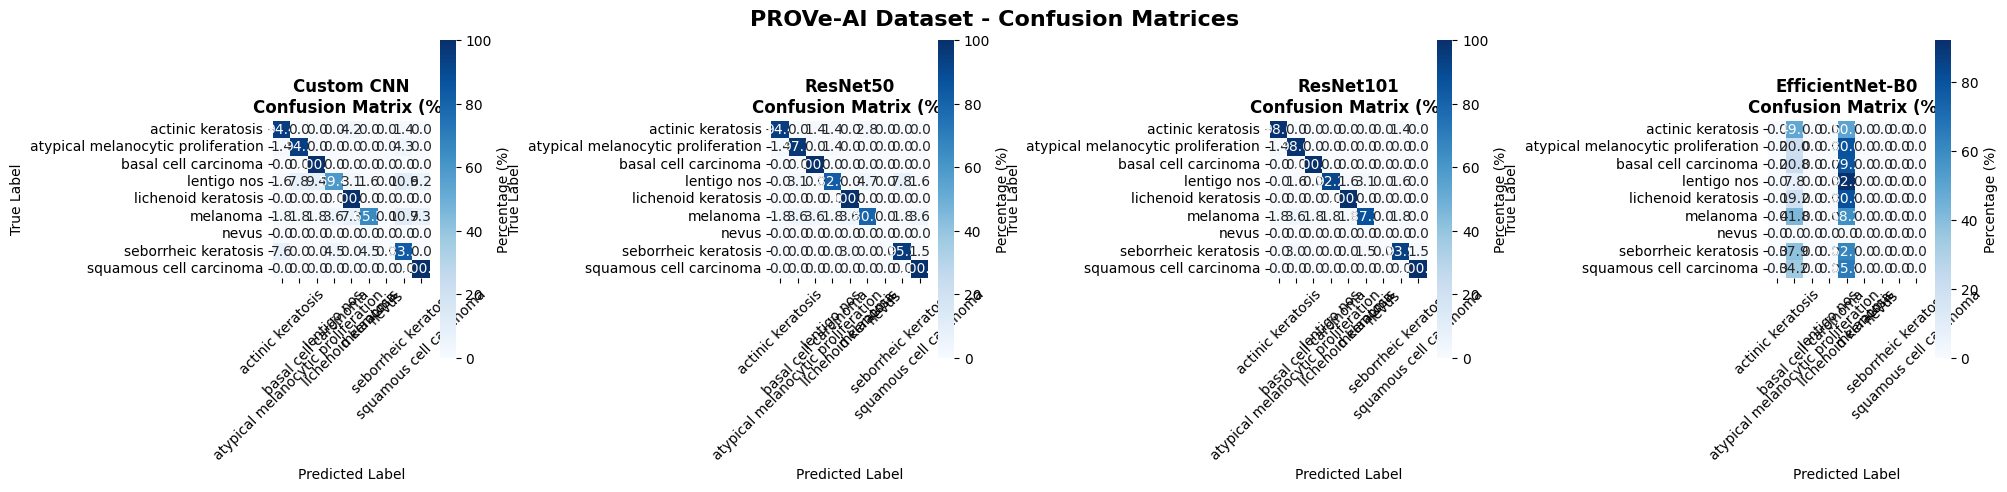


=== PROVe-AI Training and Validation Curves ===


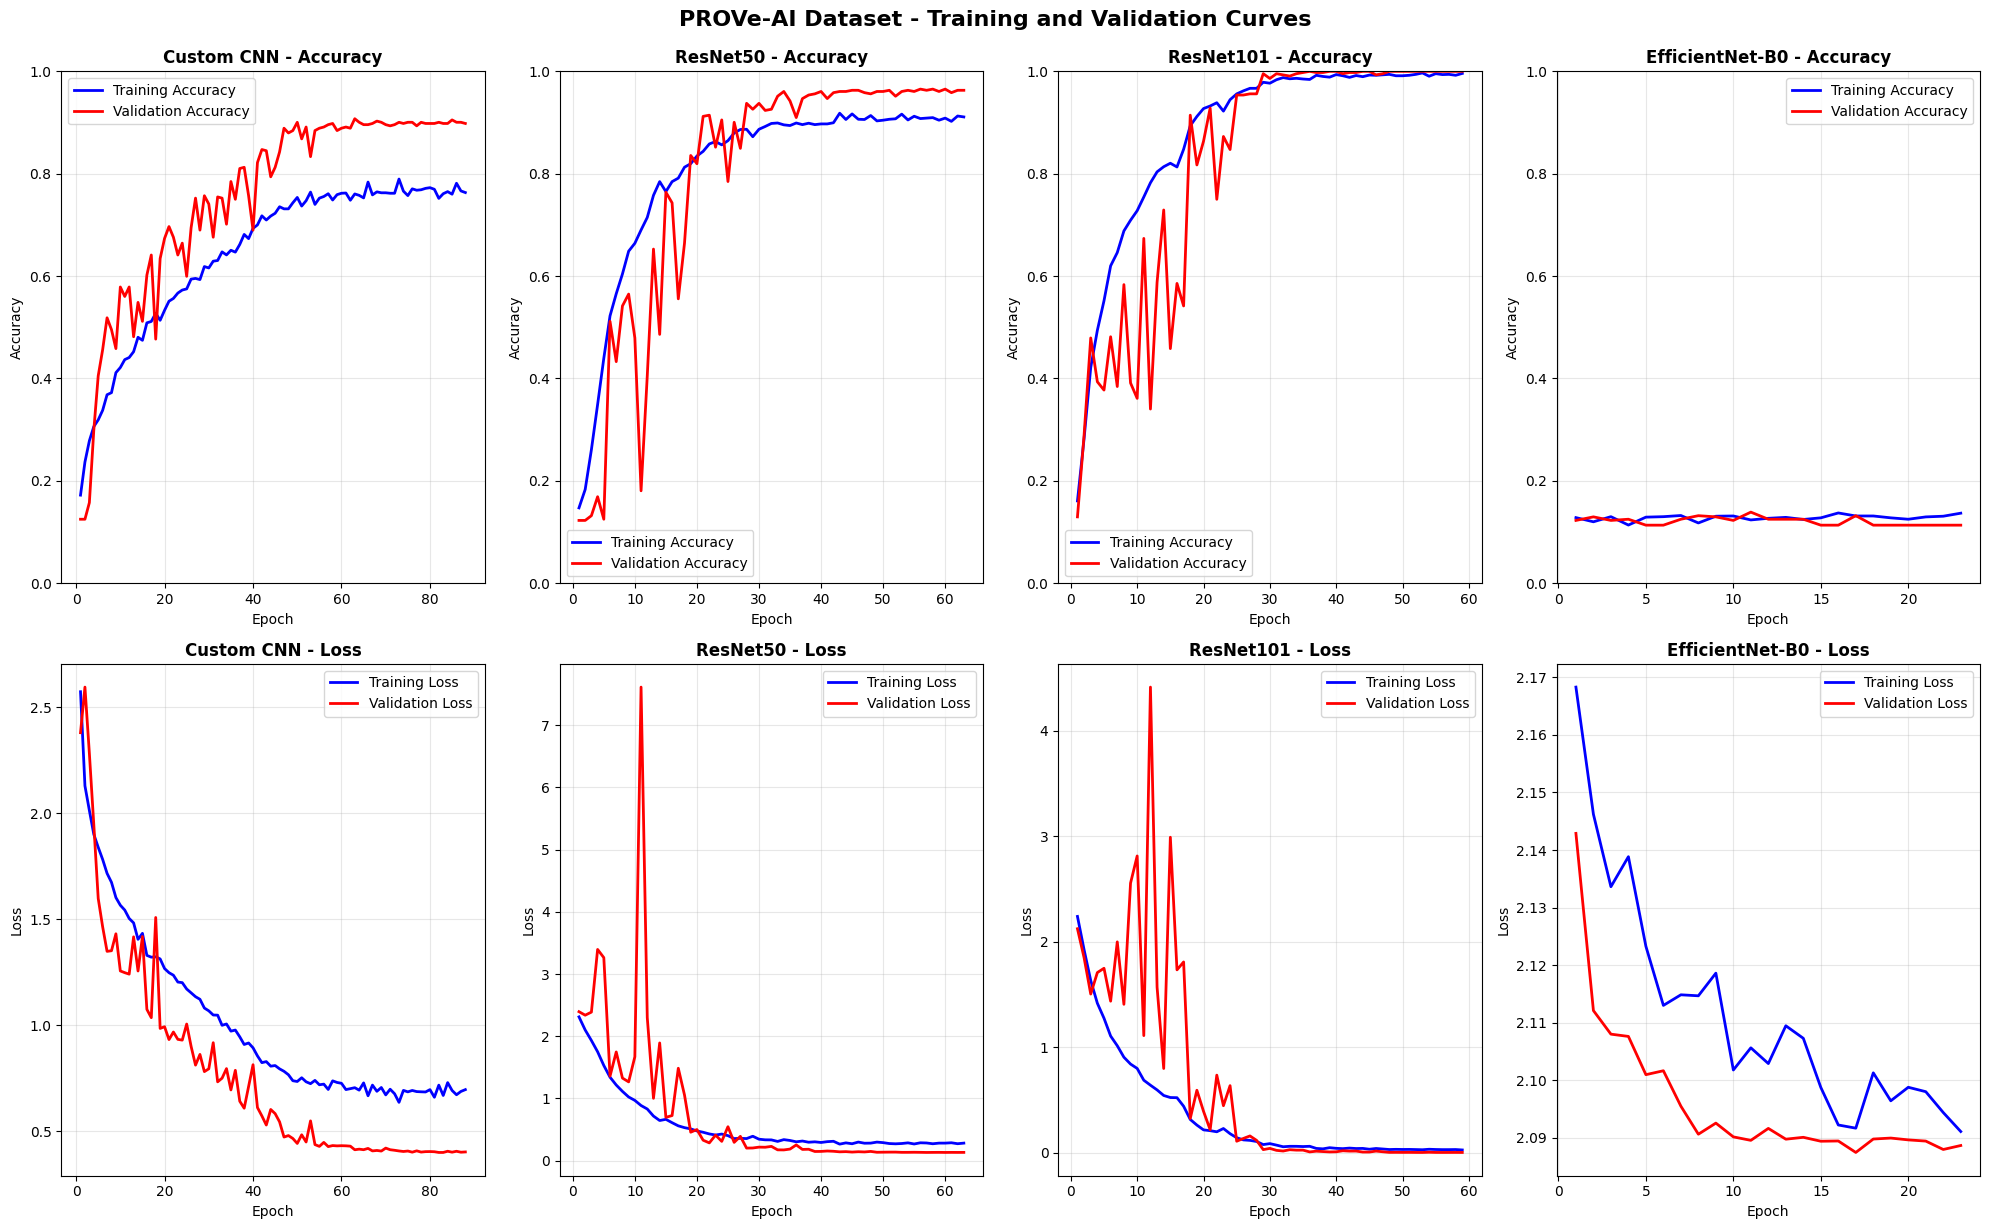


PROVE-AI CLASSIFICATION REPORTS

----------------------------------------------------------------------
Classification Report for Custom CNN (PROVe-AI Dataset)
----------------------------------------------------------------------
                                    precision    recall  f1-score   support

                 actinic keratosis      0.893     0.944     0.918        71
atypical melanocytic proliferation      0.917     0.943     0.930        70
              basal cell carcinoma      0.911     1.000     0.954        72
                       lentigo nos      0.884     0.594     0.710        64
               lichenoid keratosis      0.890     1.000     0.942        73
                          melanoma      0.900     0.655     0.758        55
                             nevus      0.000     0.000     0.000         0
              seborrheic keratosis      0.764     0.833     0.797        66
           squamous cell carcinoma      0.901     1.000     0.948        73

      

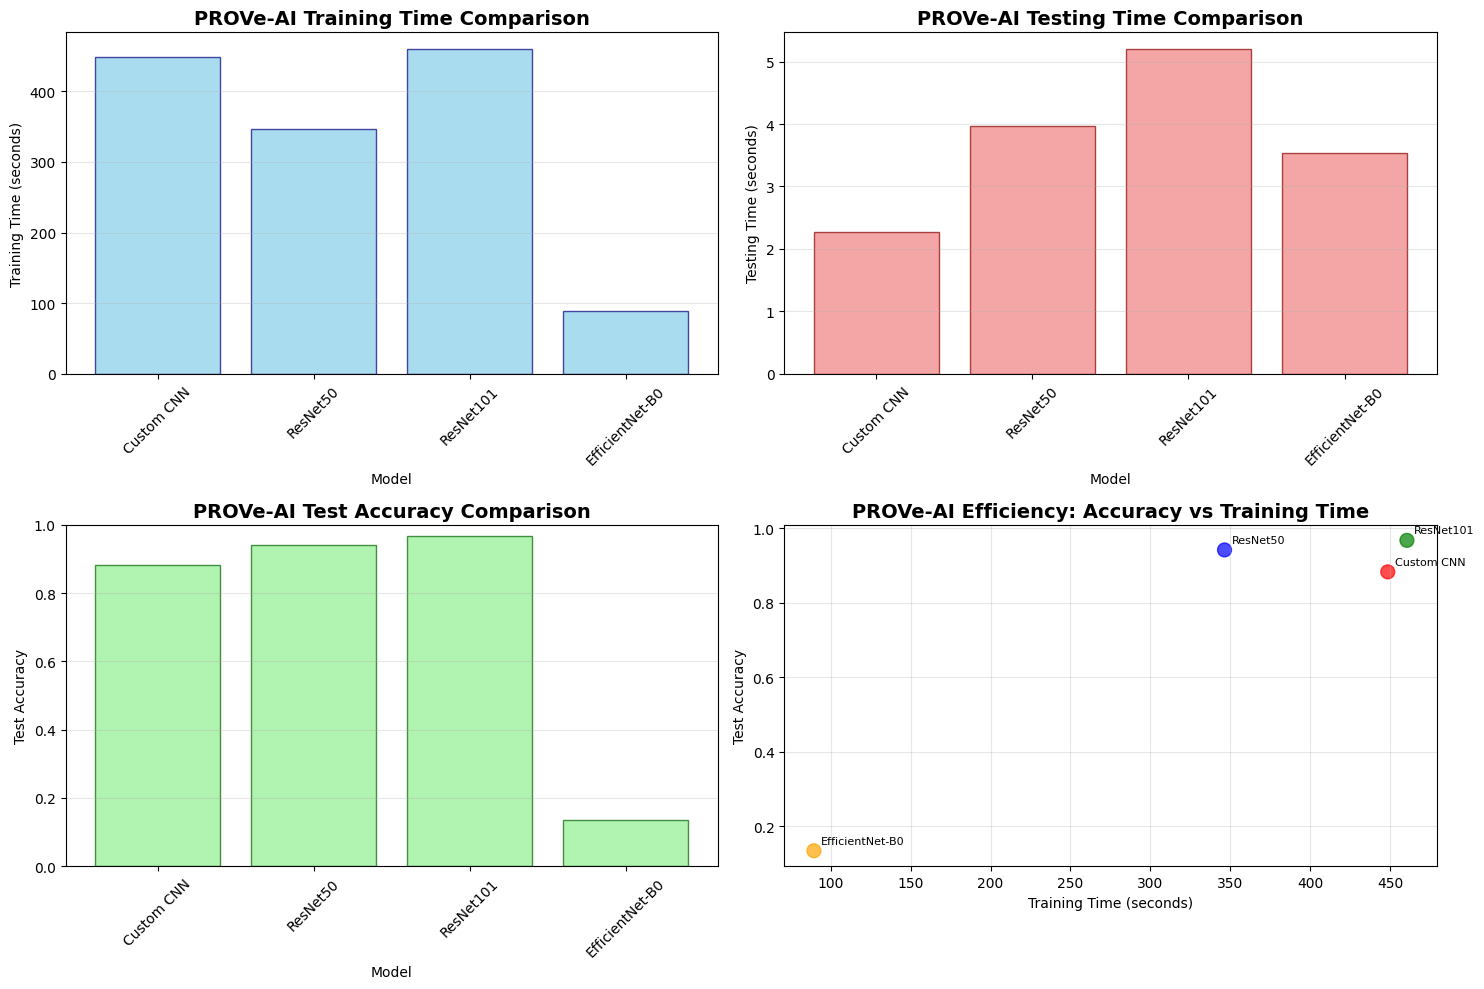


PROVE-AI FINAL PERFORMANCE SUMMARY
          Model Test Accuracy Precision (macro) Recall (macro) F1-Score (macro) Training Time (min) Parameters
     Custom CNN        0.8824             0.784          0.774            0.773                7.48    458,441
       ResNet50        0.9412             0.837          0.833            0.834                5.77 24,114,569
      ResNet101        0.9669             0.859          0.856            0.857                7.68 43,185,033
EfficientNet-B0        0.1342             0.027          0.112            0.042                1.49  4,379,820

🏆 BEST PERFORMING MODEL: ResNet101 with 0.9669 accuracy

PROVE-AI MODEL COMPARISON COMPLETED SUCCESSFULLY!

=== Saving PROVe-AI Results to Files ===
✓ Model summary saved: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\PROVe-AI datset\augmented data\model_results\prove_ai_model_summary_20250619_160217.csv
✓ Time repo

In [26]:
# After your augmentation pipeline completes:
model_results = run_prove_ai_complete_pipeline(results)

# Best performing model
best_model_name = max(model_results['trainer'].test_accuracies.items(), key=lambda x: x[1])[0]
print(f"Best model: {best_model_name}")